# Exploratory Data Analysis (EDA)


Perform EDA on US stocks and ETFs collected from Yahoo Finance.



## 1. Import Libraries

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
import time 
warnings.filterwarnings("ignore")

plt.style.use('default')

pd.set_option('display.max_columns', None)


# 2. Load Datasets

The datasets generated during Week 2 are loaded.

The datasets include:

- Adjusted close prices
- Daily returns
- Log returns
- Normalized prices
- Rolling volatility

In [49]:
adj_close = pd.read_csv(
    "../data/cleaned/adj_close_cleaned.csv",
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)

log_returns = pd.read_csv(
    "../data/processed/log_returns.csv",
    index_col=0,
    parse_dates=True
)

normalized_prices = pd.read_csv(
    "../data/processed/normalized_prices.csv",
    index_col=0,
    parse_dates=True
)

rolling_volatility = pd.read_csv(
    "../data/processed/rolling_volatility.csv",
    index_col=0,
    parse_dates=True
)

assert returns.index[-1] == adj_close.index[-1]

row_diff = len(adj_close) - len(returns)

assert row_diff in [0, 1]

print("adj_close shape:", adj_close.shape)
print("returns shape:", returns.shape)

print("adj_close start:", adj_close.index[0])
print("adj_close end:", adj_close.index[-1])

print("returns start:", returns.index[0])
print("returns end:", returns.index[-1])

print("Row Difference:", row_diff)

print(f"Adj Close Shape: {adj_close.shape}")

print(f"Returns Shape: {returns.shape}")

print("Datasets loaded successfully.")



adj_close shape: (2119, 109)
returns shape: (2118, 109)
adj_close start: 2018-01-02 00:00:00
adj_close end: 2026-06-08 00:00:00
returns start: 2018-01-03 00:00:00
returns end: 2026-06-08 00:00:00
Row Difference: 1
Adj Close Shape: (2119, 109)
Returns Shape: (2118, 109)
Datasets loaded successfully.


## 3. Define Asset Universe

The ETF and stock universes are defined once here and reused throughout the notebook.

In [50]:
etf_tickers = [
    'SPY',
    'QQQ',
    'IWM',
    'DIA',
    'XLK',
    'XLF',
    'XLV',
    'XLE',
    'XLY',
    'XLP',
    'XLI',
    'XLU',
    'VNQ',
    'GLD',
    'SLV',
    'TLT'
]

available_etfs = [
    ticker for ticker in etf_tickers
    if ticker in returns.columns
]

stock_columns = [
    col for col in returns.columns
    if col not in available_etfs
]

stock_returns = returns[stock_columns]
etf_returns = returns[available_etfs]

print("Number of Stocks:", len(stock_columns))
print("Number of ETFs:", len(available_etfs))

##Most recent 252 trading days
recent_prices = adj_close.tail(252)
recent_returns = returns.tail(252)
recent_log_returns = log_returns.tail(252)
recent_stock_returns = recent_returns[stock_columns]
recent_etf_returns = recent_returns[available_etfs]

print("Recent period:",
    recent_returns.index[0].date(),
    "to",
    recent_returns.index[-1].date()
)

print(
    "Trading Days:",
    len(recent_returns)
)

Number of Stocks: 94
Number of ETFs: 15
Recent period: 2025-06-06 to 2026-06-08
Trading Days: 252


In [51]:
company_info = {}

for ticker in stock_columns:

    try:
        company_info[ticker] = (yf.Ticker(ticker).info.get("longName"))
        time.sleep(0.5)

    except Exception:
        company_info[ticker] = None


def clean_company_name(name):
    if pd.isna(name) or name is None:
        return None
    remove_words = [
        "Class A",
        "Class B",
        "Class C",
        "Common Stock"]

    for word in remove_words:
        name = name.replace(word, "")
    return name.strip()


def remove_same_company_pairs(pair_df,asset1_col,asset2_col):

    pair_df = pair_df.copy()

    pair_df["Company_1"] = pair_df[asset1_col].map(
        lambda x: clean_company_name(
            company_info.get(x))
    )

    pair_df["Company_2"] = pair_df[asset2_col].map(
        lambda x: clean_company_name(
            company_info.get(x))
    )

    pair_df = pair_df[
        pair_df["Company_1"] != pair_df["Company_2"]
    ]

    return pair_df

# 4. Dataset Overview
To verify data is suitable for EDA we need to check these
- Number of assets
- Trading period
- Missing values
- Data types
- Summary statistics

In [5]:
print("Adjusted Close Shape:", adj_close.shape)
print("Returns Shape:", returns.shape)
print("Log Returns Shape:", log_returns.shape)
print("Rolling Volatility Shape:", rolling_volatility.shape)

Adjusted Close Shape: (2119, 109)
Returns Shape: (2118, 109)
Log Returns Shape: (2118, 109)
Rolling Volatility Shape: (2118, 109)


In [6]:
adj_close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2119 entries, 2018-01-02 to 2026-06-08
Columns: 109 entries, AAPL to XOM
dtypes: float64(109)
memory usage: 1.8 MB


In [7]:
adj_close.describe()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,COP,COST,CRM,CSCO,CVS,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NFLX,NOW,NVDA,ORCL,PANW,PEP,PFE,PG,PGR,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,SYK,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
count,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000,2119.000000
mean,142.155384,120.070469,95.445415,158.489671,123.827709,99.588391,220.898880,145.138854,47.340464,47.188732,97.317474,171.122294,232.986284,32.611972,111.029838,660.830326,315.149259,83.573440,58.107234,245.442758,190.341473,73.355309,512.203095,205.321402,47.498925,63.908709,114.631755,310.614855,61.986912,188.655364,317.325660,116.494828,176.550784,103.563769,69.898113,197.085163,39.509534,126.047057,125.548471,355.792911,268.389730,165.424767,25.248714,141.224256,40.573378,302.973700,181.793589,141.972620,150.191714,448.242451,51.833653,298.648461,396.713148,375.329747,171.077603,62.169385,359.749501,222.611906,330.350265,37.621141,79.000190,78.406951,270.746178,95.589426,61.482928,53.143681,104.534531,51.968028,95.558092,96.185508,130.434068,28.603033,123.162768,121.873261,96.662312,88.291481,113.929965,337.888309,91.691470,60.976674,350.880255,408.479574,94.301438,252.262530,17.249953,77.357322,101.342571,444.651690,132.677612,194.188452,144.054313,362.594014,187.395467,221.554188,75.883232,37.550046,60.807767,86.805297,47.510626,54.292297,31.593455,33.752965,97.638557,75.226008,62.758597,30.036774,114.117412,78.613375,76.859234
std,71.578711,51.610406,22.081389,67.064671,81.905569,71.351170,58.033748,50.628275,41.754942,33.642926,104.396874,80.802153,71.852305,9.218871,48.421916,228.600350,108.038230,44.541282,20.304239,161.246520,65.926047,28.866078,275.883380,55.645987,13.652380,13.191800,34.444193,133.859724,50.141441,58.644528,83.124991,26.229656,106.299867,83.590280,24.180588,81.613031,28.587757,72.140114,72.089604,206.543455,76.663478,32.290037,18.556297,61.510879,13.411341,129.359380,38.210483,29.497705,70.332225,384.949421,11.822963,116.195937,313.180309,91.897579,59.906225,53.803054,116.231837,55.645404,185.249326,11.203360,21.743493,40.953086,126.799619,110.302855,15.638589,27.208855,49.678704,62.075872,57.267974,60.687474,25.859440,5.769658,29.621446,66.145588,26.711284,36.378531,42.835183,143.457627,35.496709,19.125674,109.093691,138.463718,115.749560,75.569500,4.253866,34.162110,17.826027,131.484315,55.236605,132.720248,41.957523,115.168240,40.892993,66.907778,11.446686,4.714136,72.266058,43.932426,16.955353,26.928891,11.312558,10.110466,31.034610,35.639730,12.566321,6.924280

In [8]:
print("Missing Values:")
adj_close.isnull().sum().sort_values(ascending=False).head(10)

Missing Values:


AAPL    0
PANW    0
SPGI    0
SCHW    0
RTX     0
QQQ     0
QCOM    0
PM      0
PLD     0
PGR     0
dtype: int64

In [9]:
print("Start Date:", adj_close.index.min())
print("End Date:", adj_close.index.max())

Start Date: 2018-01-02 00:00:00
End Date: 2026-06-08 00:00:00


# 5. Price Trend Analysis


In [10]:
top_performers = (
    normalized_prices[stock_columns]
    .iloc[-1]
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

focus_assets = ['SPY'] + top_performers

The price trends of selected technology stocks and a broad market benchmark are analyzed to compare their performance and identify major market movements during the sample period.

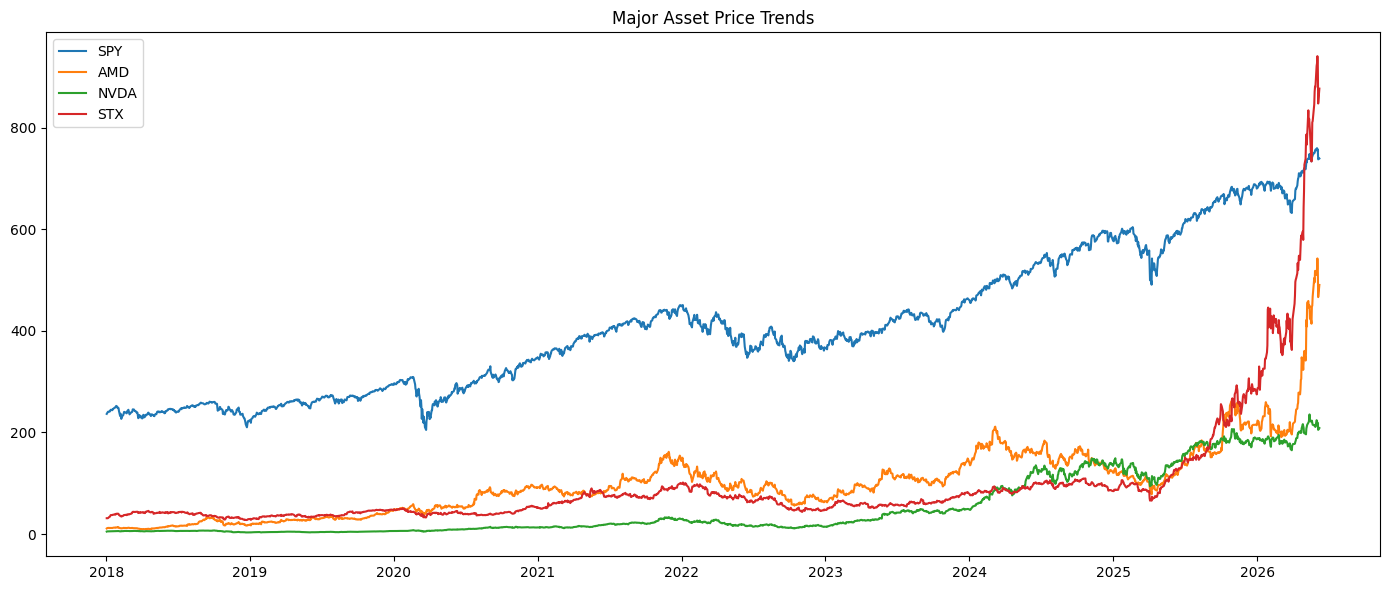

In [11]:
plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        adj_close.index,
        adj_close[asset],
        label=asset
    )

plt.title("Major Asset Price Trends")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Normalized Price Comparison

Since assets begin the sample period at different price levels, direct comparison of raw prices can be misleading. By normalizing the price level for all of them, we can make an objective judgment regarding their performance.


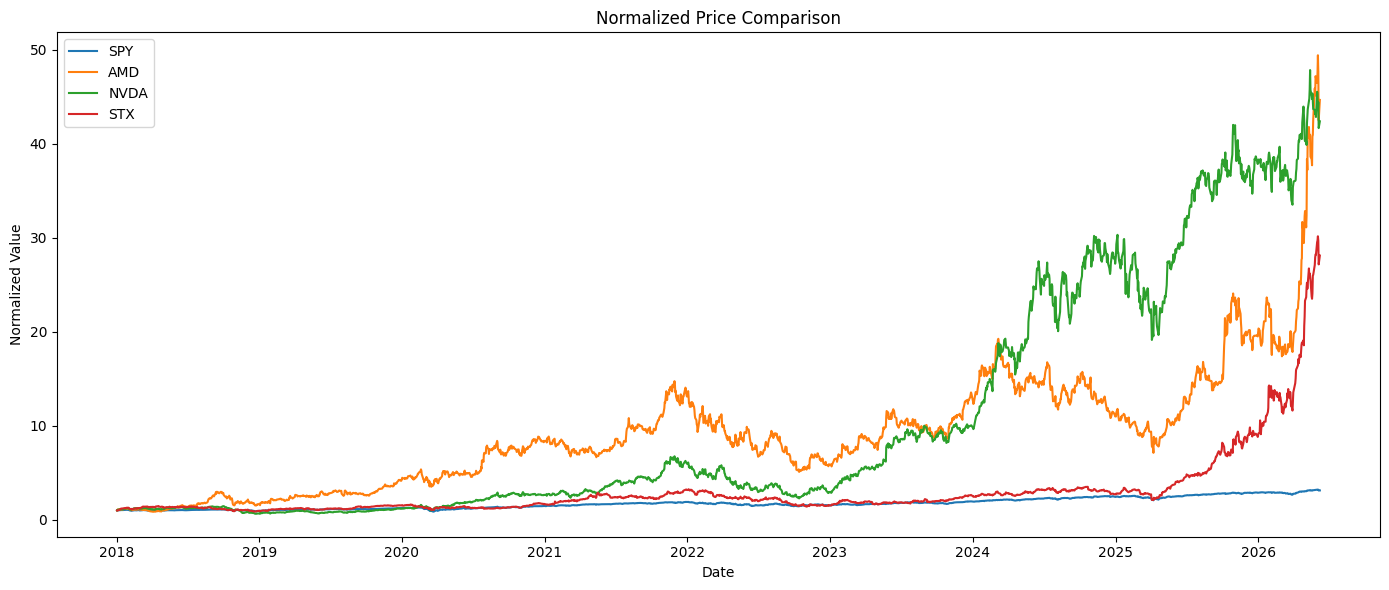

In [12]:

plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        normalized_prices.index,
        normalized_prices[asset],
        label=asset
    )

plt.title("Normalized Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Top and Bottom Performing Assets

Using normalized prices, the final value of each asset represents its cumulative growth relative to the start of the sample period.


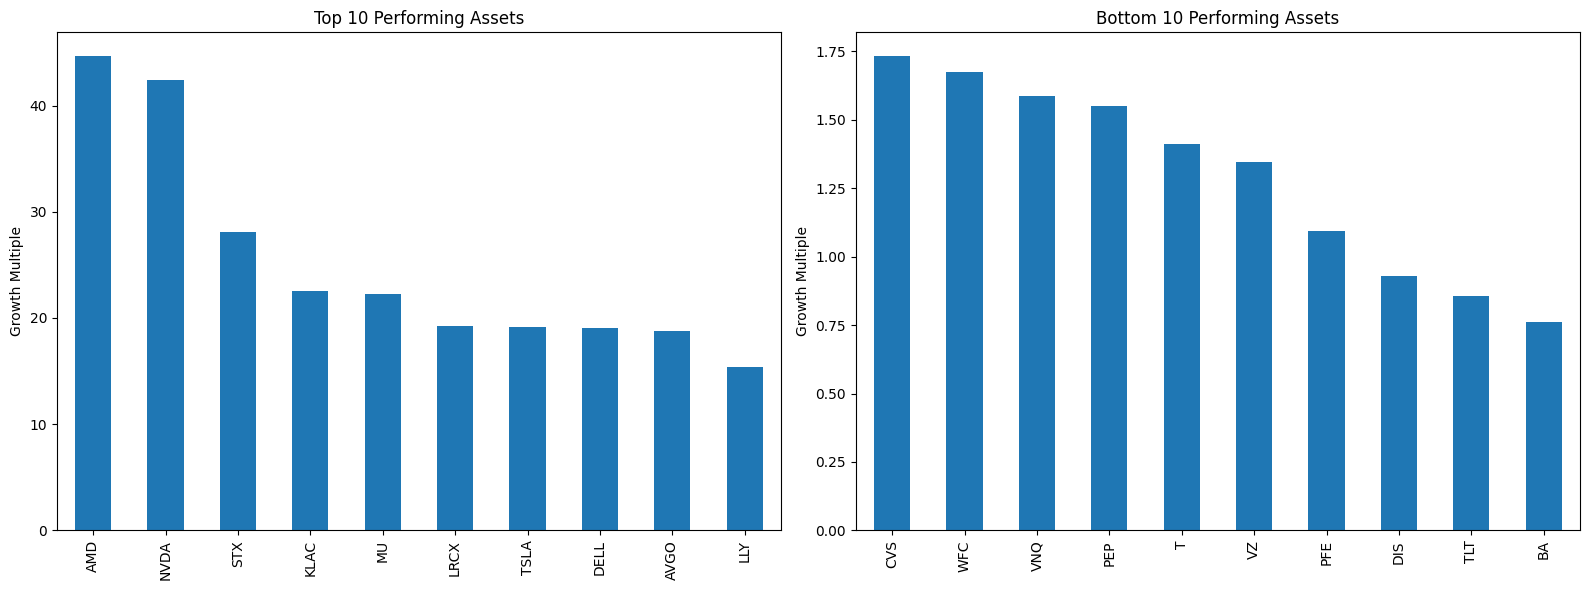

Top 10 performers:
AMD     44.656649
NVDA    42.384707
STX     28.106125
KLAC    22.524279
MU      22.288392
LRCX    19.230943
TSLA    19.137834
DELL    19.039481
AVGO    18.808096
LLY     15.342915
Name: 2026-06-08 00:00:00, dtype: float64

Bottom 10 performers:
CVS    1.733366
WFC    1.673531
VNQ    1.586645
PEP    1.551919
T      1.413219
VZ     1.347850
PFE    1.092843
DIS    0.930764
TLT    0.857296
BA     0.763275
Name: 2026-06-08 00:00:00, dtype: float64


In [13]:
performance = normalized_prices.iloc[-1].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

performance.head(10).plot(kind='bar', ax=axes[0])
axes[0].set_title("Top 10 Performing Assets")
axes[0].set_ylabel("Growth Multiple")

performance.tail(10).plot(kind='bar', ax=axes[1])
axes[1].set_title("Bottom 10 Performing Assets")
axes[1].set_ylabel("Growth Multiple")

plt.tight_layout()
plt.show()

print("Top 10 performers:")
print(performance.head(10))
print()
print("Bottom 10 performers:")
print(performance.tail(10))


# 8. Return Analysis

Returns are analysed because price levels are non-stationary and difficult to compare directly across assets.

Returns provide a standardized measure of performance.

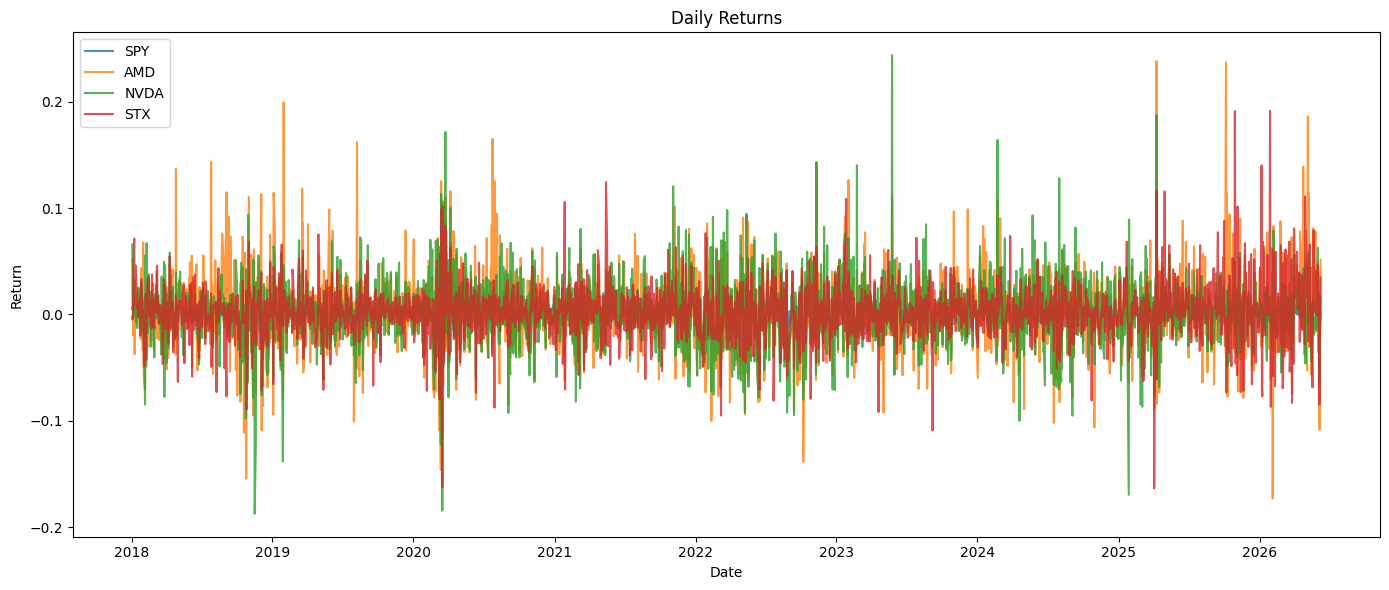

In [14]:
plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        returns.index,
        returns[asset],
        label=asset,
        alpha=0.8
    )

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Return Summary Statistics

In [15]:
return_stats = pd.DataFrame({
    'Mean Return (Daily)': returns.mean(),
    'Volatility (Daily Std)': returns.std(),
    'Min Return': returns.min(),
    'Max Return': returns.max()
})
return_stats.head()

,Mean Return (Daily),Volatility (Daily Std),Min Return,Max Return
AAPL,0.001135,0.019201,-0.128647,0.153289
ABBV,0.000699,0.016822,-0.162524,0.137673
ABT,0.000397,0.015566,-0.100389,0.109360
ADI,0.001015,0.021693,-0.166149,0.183876
AMAT,0.001504,0.028477,-0.203576,0.161058


### Outlier Detection
To show extreme market moves

In [16]:
z_scores = (
    returns - returns.mean()
) / returns.std()

outliers = (
    z_scores.abs() > 3
)

outliers.sum().sort_values(
    ascending=False
).head(10)

QCOM    42
GLW     41
MRK     40
AMGN    39
ISRG    39
TMUS    38
JNJ     38
IBM     38
KO      37
UNH     37
dtype: int64

## 10. Most Volatile Assets

The following assets exhibited the highest return volatility during the sample period, indicating greater price fluctuations and risk.

Top 10 Most Volatile Assets:
TSLA    0.626878
AMD     0.562325
MU      0.517021
NVDA    0.507083
WDC     0.505205
LRCX    0.473815
INTC    0.473379
DELL    0.466060
ANET    0.462641
AMAT    0.452056
dtype: float64


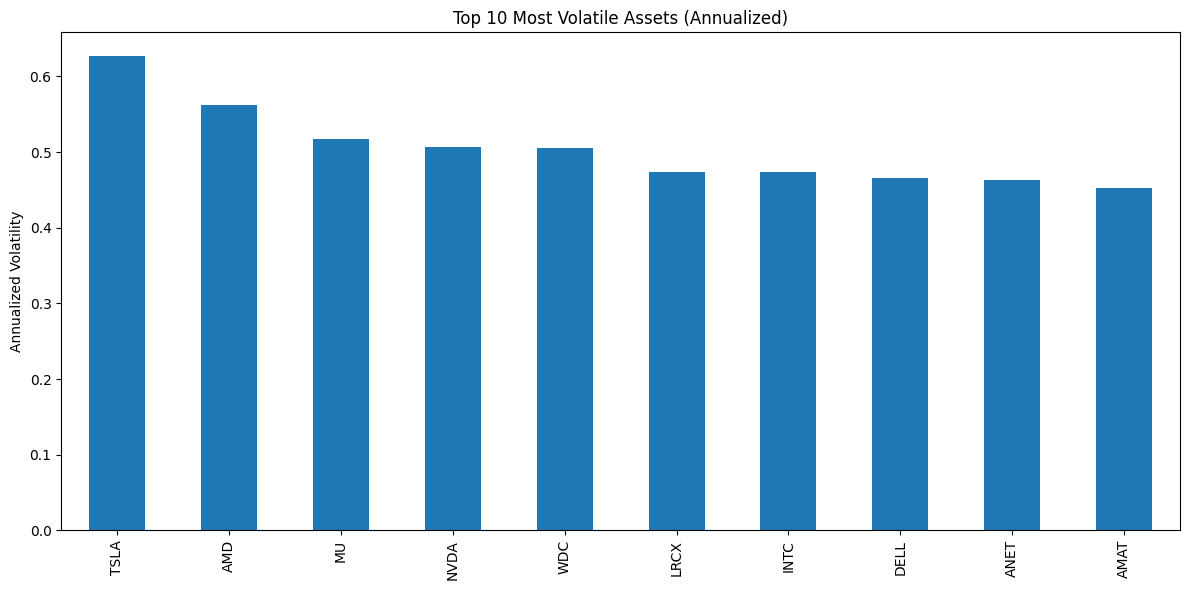

In [17]:
# Top 10 Most Volatile Assets (Annualized)

top_volatility = (returns.std()* np.sqrt(252)).sort_values(ascending=False).head(10)

print("Top 10 Most Volatile Assets:")
print(top_volatility)

plt.figure(figsize=(12,6))

top_volatility.plot(kind="bar")

plt.title( "Top 10 Most Volatile Assets (Annualized)")

plt.ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

### Least Volatile Assets

The assets below exhibited the lowest return volatility during the sample period, indicating more stable price movements and lower levels of market risk.

Top 10 Least Volatile Assets:
TLT    0.154920
XLP    0.155683
GLD    0.166553
XLV    0.174385
DIA    0.187861
SPY    0.192061
KO     0.192544
JNJ    0.194650
PG     0.200796
XLU    0.202591
dtype: float64


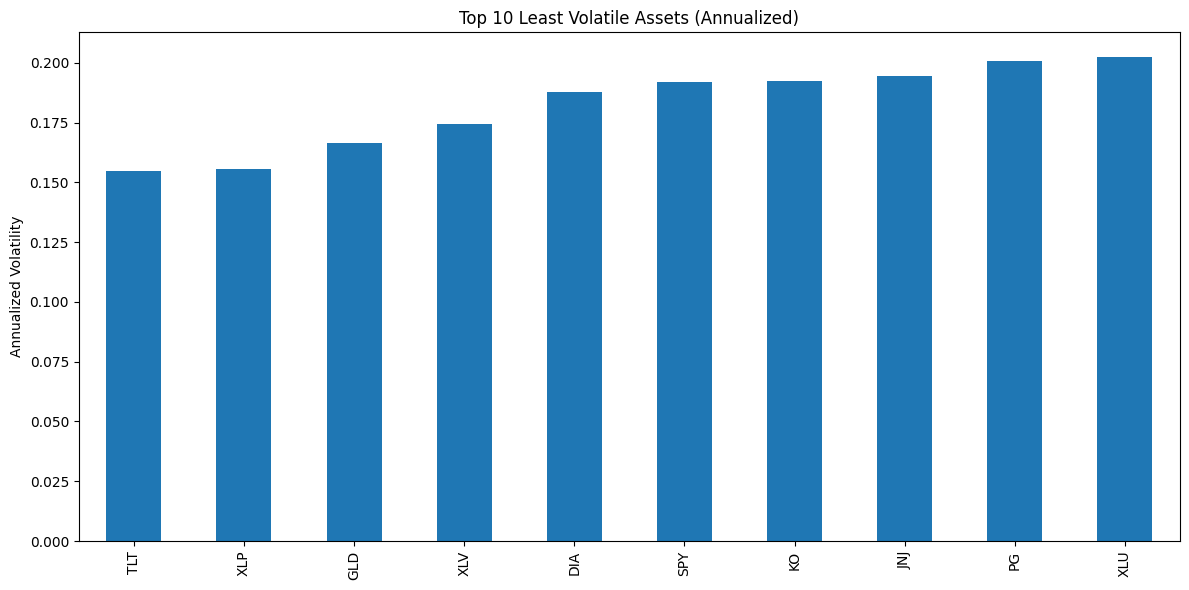

In [18]:
# Top 10 Least Volatile Assets (Annualized)

low_volatility = (returns.std()* np.sqrt(252)).sort_values(ascending=True).head(10)

print("Top 10 Least Volatile Assets:")
print(low_volatility)

plt.figure(figsize=(12,6))

low_volatility.plot(kind="bar")

plt.title("Top 10 Least Volatile Assets (Annualized)")

plt.ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

## 11. Rolling Volatility Analysis
It shows 
- Covid crash
- Bear market
- Market Stress periods

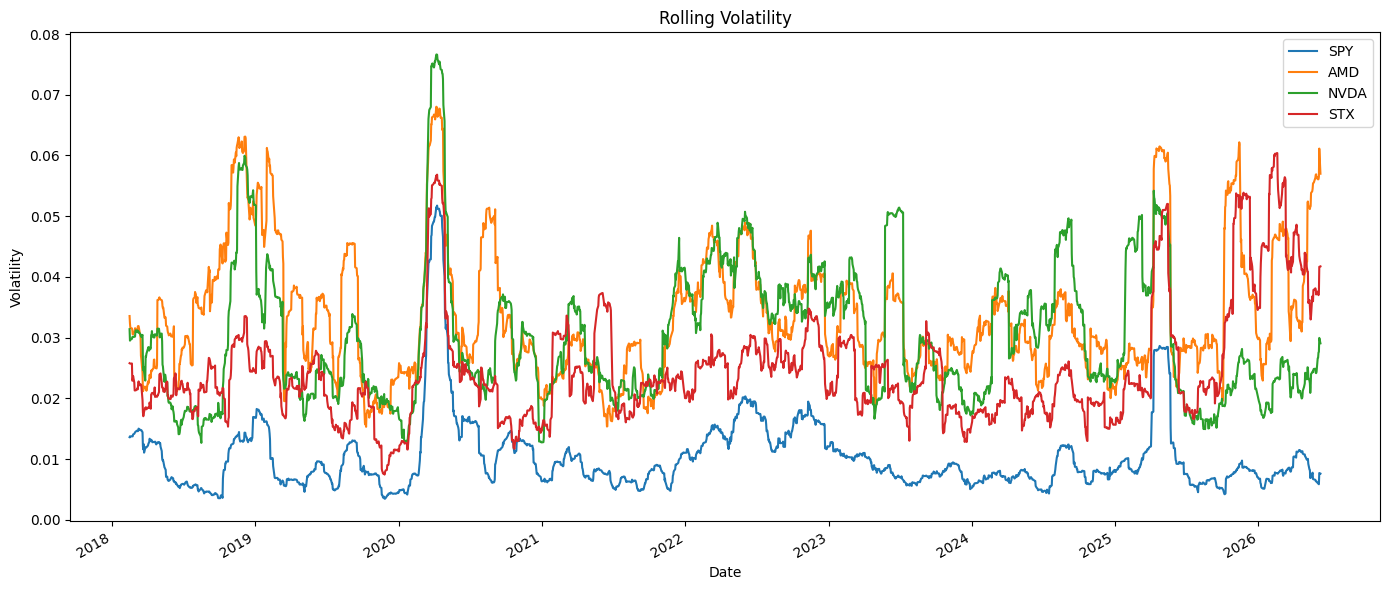

In [19]:
rolling_volatility[focus_assets].plot(
    figsize=(14,6)
)

plt.title("Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

## 12. Return Distribution Analysis

The distribution of returns is examined to understand the frequency of different return outcomes and assess the presence of skewness and extreme market movements.

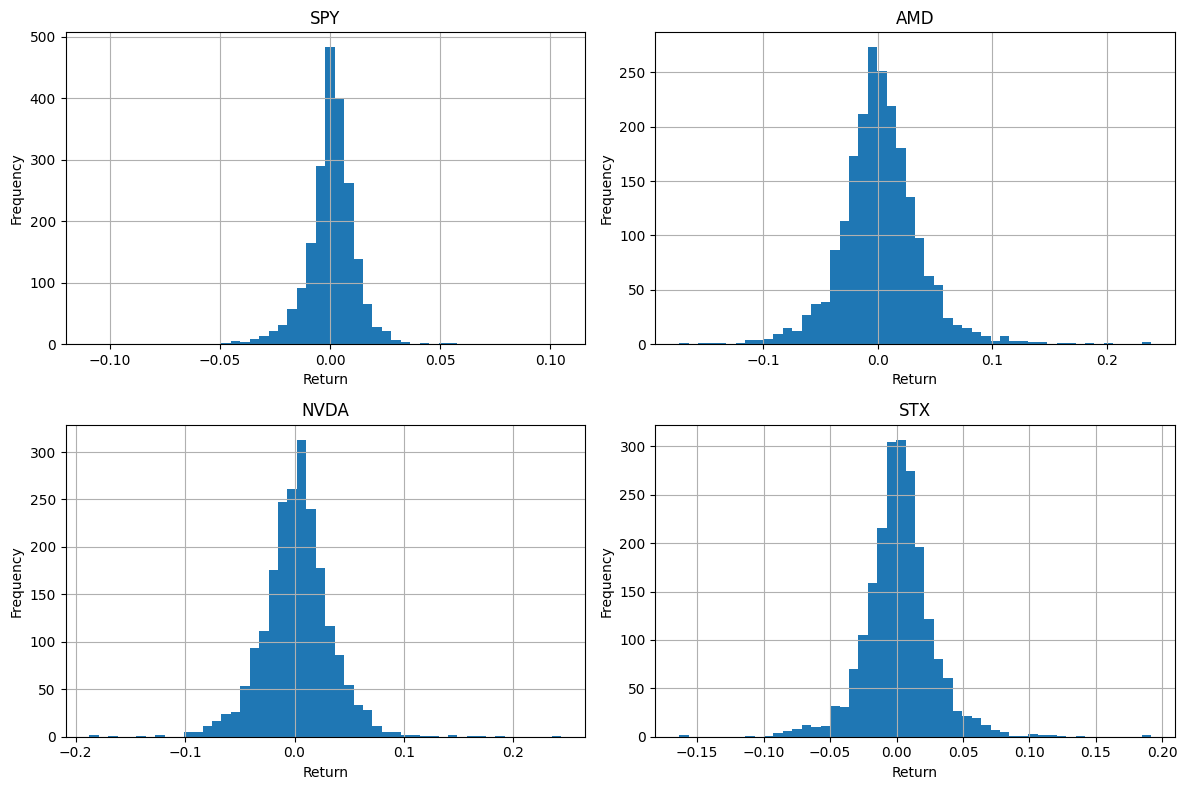

In [20]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, asset in zip(
    axes.flatten(),
    focus_assets
):

    returns[asset].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(asset)
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 13. Skewness and Kurtosis

In [21]:
distribution_stats = pd.DataFrame({
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})

distribution_stats.head()

,Skewness,Kurtosis
AAPL,0.150221,6.412424
ABBV,-0.901630,12.748421
ABT,-0.141474,6.592394
ADI,0.215795,7.608539
AMAT,-0.211628,3.403171


### Assets with Highest Kurtosis

Ranking assets by kurtosis helps identify securities whose return distributions exhibit the strongest tail behavior and the greatest tendency toward extreme return events.

In [22]:
distribution_stats.sort_values(
    'Kurtosis',
    ascending=False
).head(10)

,Skewness,Kurtosis
ORCL,2.149067,33.659840
MCD,0.355350,29.758432
WELL,0.092098,27.830334
CVX,-0.321985,22.998104
DELL,1.305045,20.794732
UNH,-1.355318,20.688308
VNQ,-1.091356,19.690230
DIA,-0.472760,18.957197
LOW,-0.951847,18.795056
NFLX,-0.875787,18.699203


## 14.Annualized Return

In [23]:
n_days = len(returns)

annual_return = (
    (1 + returns).prod()** (252 / n_days)- 1
)

annual_return.sort_values(
    ascending=False
).head(10)

AMD     0.571461
NVDA    0.561729
STX     0.487232
KLAC    0.448567
MU      0.446754
LRCX    0.421578
TSLA    0.420757
DELL    0.419886
AVGO    0.417822
LLY     0.383883
dtype: float64

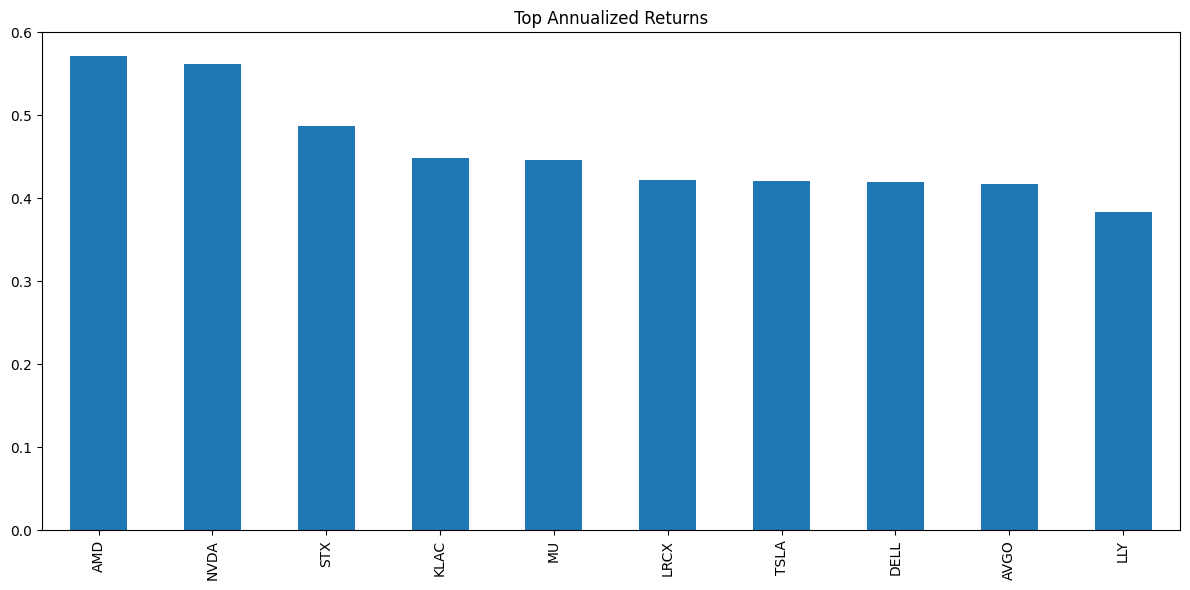

In [24]:
annual_return.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Top Annualized Returns"
)
plt.tight_layout()
plt.show()

## 15. Correlation Matrix

The correlation matrix summarizes pairwise relationships between asset returns, where values close to 1 indicate strong positive co-movement and values close to -1 indicate strong inverse relationships.

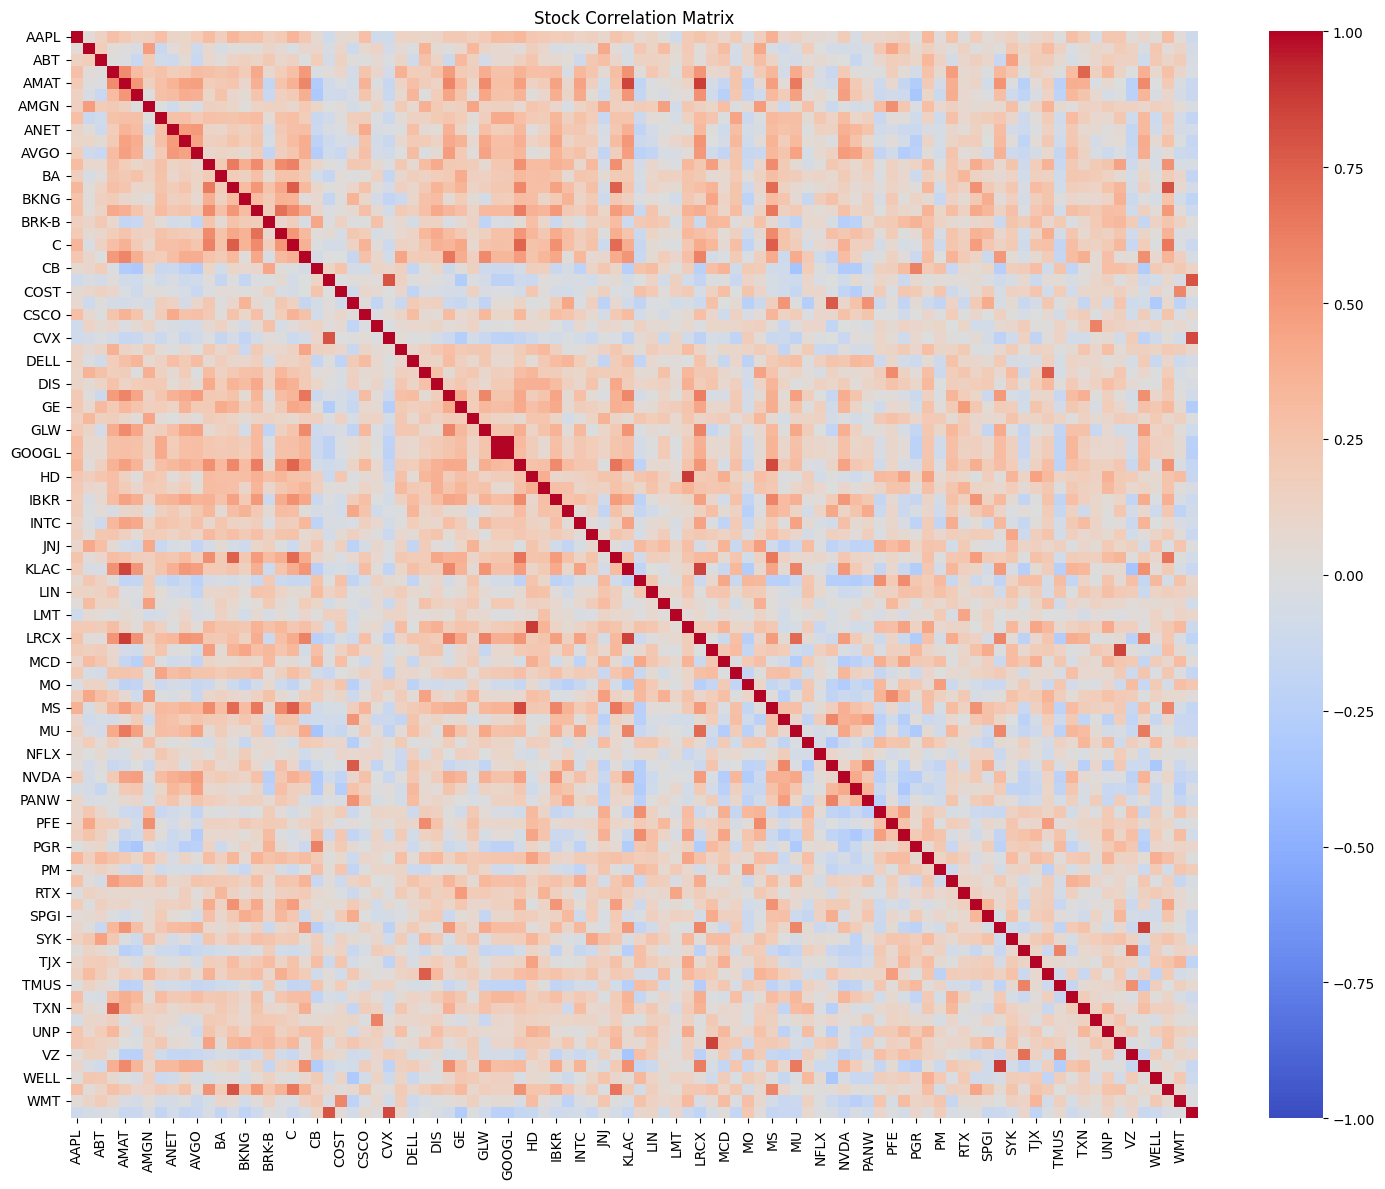

In [25]:
stock_corr = recent_stock_returns.corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    stock_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Stock Correlation Matrix"
)

plt.tight_layout()
plt.show()

## 16. Top Correlated Stock Pairs

To identify potential candidate pairs, the stock return correlation matrix is examined. Only the upper triangle of the matrix is retained to avoid duplicate pair combinations.

The top 20 most highly correlated stock pairs are selected and enriched with company information to improve interpretability. Pairs representing the same company through multiple share classes are removed to ensure that the analysis focuses on relationships between distinct firms.


In [26]:
upper_stock = stock_corr.where(
    np.triu(
        np.ones(stock_corr.shape),
        k=1
    ).astype(bool)
)

top_stock_pairs = (
    upper_stock
    .stack()
    .reset_index()
)

top_stock_pairs.columns = [
    "Stock_1",
    "Stock_2",
    "Correlation"
]

top_stock_pairs = (
    top_stock_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(20)
)

top_stock_pairs

,Stock_1,Stock_2,Correlation
3326,GOOG,GOOGL,0.996759
3623,HD,LOW,0.880636
428,AMAT,LRCX,0.870888
7327,STX,WDC,0.870794
5069,MA,V,0.859181
4376,KLAC,LRCX,0.857795
422,AMAT,KLAC,0.848624
3536,GS,MS,0.832065
2537,CVX,XOM,0.828351
1313,BAC,WFC,0.800673


In [27]:
# Unique tickers appearing in top pairs
top_stock_pairs = remove_same_company_pairs(
    top_stock_pairs,
    "Stock_1",
    "Stock_2"
)
top_stock_pairs.head(10)


,Stock_1,Stock_2,Correlation,Company_1,Company_2
3623,HD,LOW,0.880636,"The Home Depot, Inc.","Lowe's Companies, Inc."
428,AMAT,LRCX,0.870888,"Applied Materials, Inc.",Lam Research Corporation
7327,STX,WDC,0.870794,Seagate Technology Holdings plc,Western Digital Corporation
5069,MA,V,0.859181,Mastercard Incorporated,Visa Inc.
4376,KLAC,LRCX,0.857795,KLA Corporation,Lam Research Corporation
422,AMAT,KLAC,0.848624,"Applied Materials, Inc.",KLA Corporation
3536,GS,MS,0.832065,"The Goldman Sachs Group, Inc.",Morgan Stanley
2537,CVX,XOM,0.828351,Chevron Corporation,Exxon Mobil Corporation
1313,BAC,WFC,0.800673,Bank of America Corporation,Wells Fargo & Company
2067,COP,XOM,0.794827,ConocoPhillips,Exxon Mobil Corporation


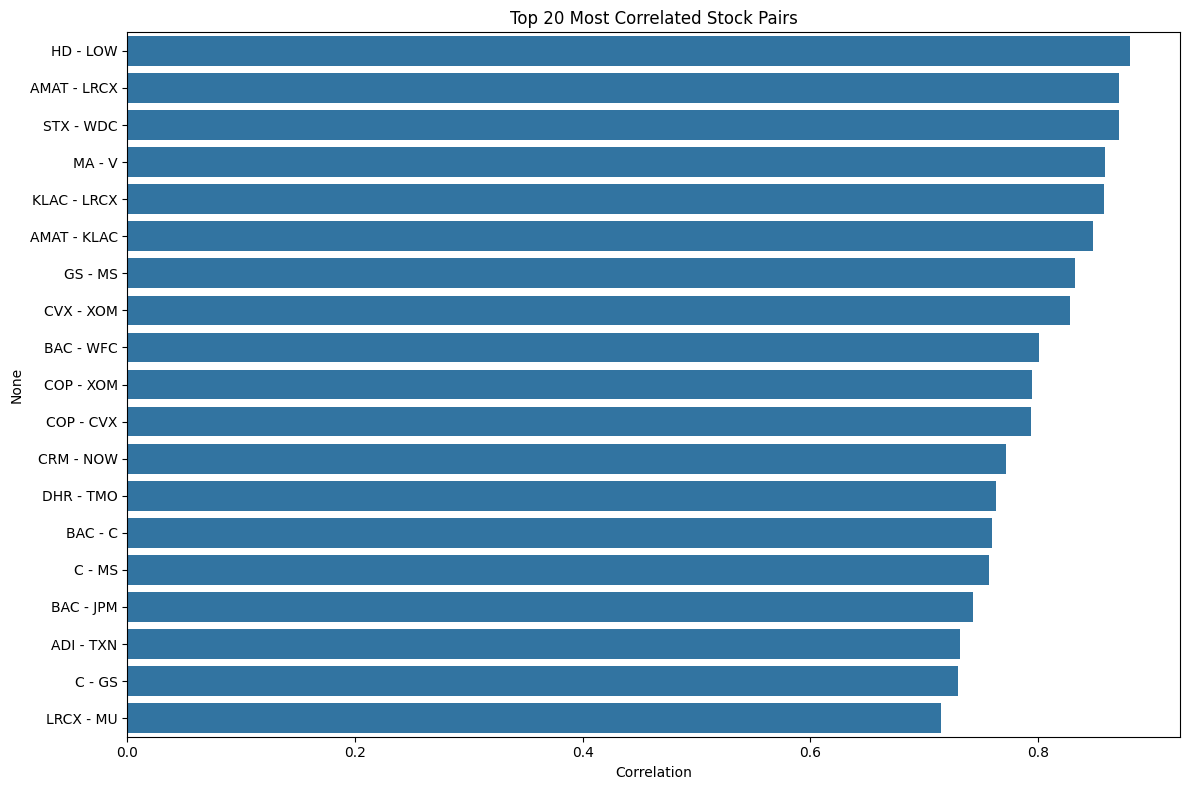

In [28]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_stock_pairs,
    x="Correlation",
    y=top_stock_pairs["Stock_1"]
      + " - "
      + top_stock_pairs["Stock_2"]
)

plt.title(
    "Top 20 Most Correlated Stock Pairs"
)

plt.tight_layout()
plt.show()

In [29]:
sector_info = {}

for ticker in stock_columns:

    try:

        sector_info[ticker] = (
            yf.Ticker(ticker)
            .info
            .get("sector")
        )

        time.sleep(0.5)

    except Exception:

        sector_info[ticker] = "Unknown"

In [30]:
top_stock_pairs["Sector_1"] = (
    top_stock_pairs["Stock_1"]
    .map(sector_info)
)


top_stock_pairs["Sector_2"] = (
    top_stock_pairs["Stock_2"]
    .map(sector_info)
)

top_stock_pairs.head()

,Stock_1,Stock_2,Correlation,Company_1,Company_2,Sector_1,Sector_2
3623,HD,LOW,0.880636,"The Home Depot, Inc.","Lowe's Companies, Inc.",Consumer Cyclical,Consumer Cyclical
428,AMAT,LRCX,0.870888,"Applied Materials, Inc.",Lam Research Corporation,Technology,Technology
7327,STX,WDC,0.870794,Seagate Technology Holdings plc,Western Digital Corporation,Technology,Technology
5069,MA,V,0.859181,Mastercard Incorporated,Visa Inc.,Financial Services,Financial Services
4376,KLAC,LRCX,0.857795,KLA Corporation,Lam Research Corporation,Technology,Technology


# 17. ETF Correlation Matrix

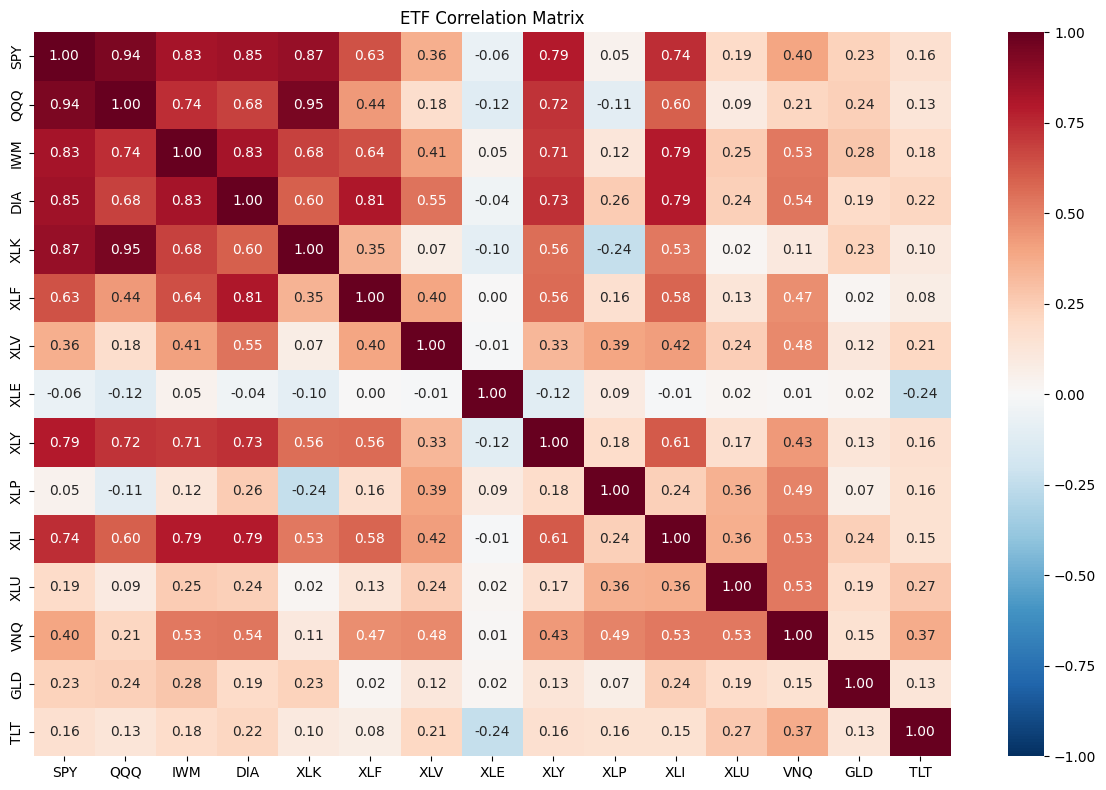

In [31]:
etf_corr = recent_etf_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    etf_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.title("ETF Correlation Matrix")

plt.tight_layout()
plt.show()

## 18. Top Correlated ETF Pairs

In [32]:
upper_etf = etf_corr.where(
    np.triu(
        np.ones(etf_corr.shape),
        k=1
    ).astype(bool)
)

top_etf_pairs = (
    upper_etf
    .stack()
    .reset_index()
)

top_etf_pairs.columns = [
    "ETF_1",
    "ETF_2",
    "Correlation"
]

top_etf_pairs = (
    top_etf_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(15)
)

top_etf_pairs

,ETF_1,ETF_2,Correlation
19,QQQ,XLK,0.950908
1,SPY,QQQ,0.943531
4,SPY,XLK,0.870975
3,SPY,DIA,0.849874
2,SPY,IWM,0.831735
33,IWM,DIA,0.830606
50,DIA,XLF,0.808329
8,SPY,XLY,0.794560
40,IWM,XLI,0.793892
55,DIA,XLI,0.791794


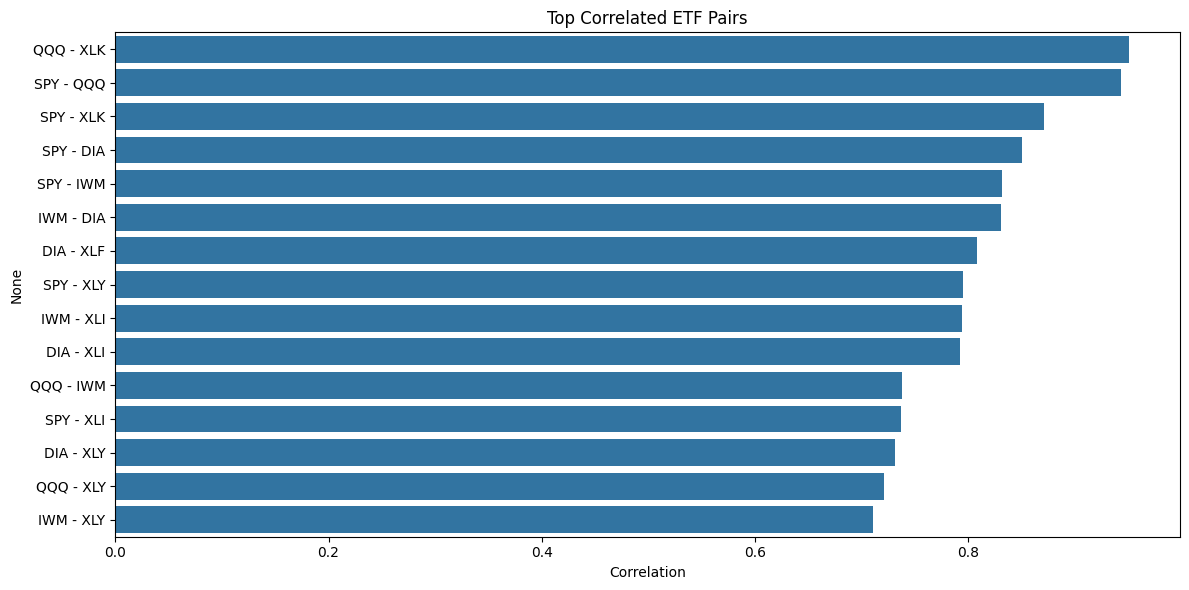

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_etf_pairs,
    x="Correlation",
    y=(
        top_etf_pairs["ETF_1"]
        + " - "
        + top_etf_pairs["ETF_2"]
    )
)

plt.title(
    "Top Correlated ETF Pairs"
)

plt.tight_layout()
plt.show()

## 19. Stocks vs. ETFs Comparison

To assess whether ETFs offer more stable relationships than individual stocks, the two groups are compared across correlation behaviour, correlation stability, and volatility.

### 19.1 Distribution of Pairwise Correlations

In [34]:
# Convert correlation matrix to pairwise format and remove same-company pairs before calculating
# average stock correlation and correlation distribution.

all_stock_pairs = (upper_stock.stack().reset_index())
all_stock_pairs.columns = [ "Stock_1","Stock_2","Correlation"]
all_stock_pairs = remove_same_company_pairs(all_stock_pairs, "Stock_1","Stock_2")

stock_corr_values = all_stock_pairs["Correlation"]
etf_corr_values = upper_etf.stack()

print("Average Stock Correlation:")
print(round(stock_corr_values.mean(), 3))

print()

print("Average ETF Correlation:")
print(round(etf_corr_values.mean(), 3))

print()

print("Stock Correlation Std:")
print(round(stock_corr_values.std(), 3))

print()

print("ETF Correlation Std:")
print(round(etf_corr_values.std(), 3))

Average Stock Correlation:
0.108

Average ETF Correlation:
0.323

Stock Correlation Std:
0.174

ETF Correlation Std:
0.286


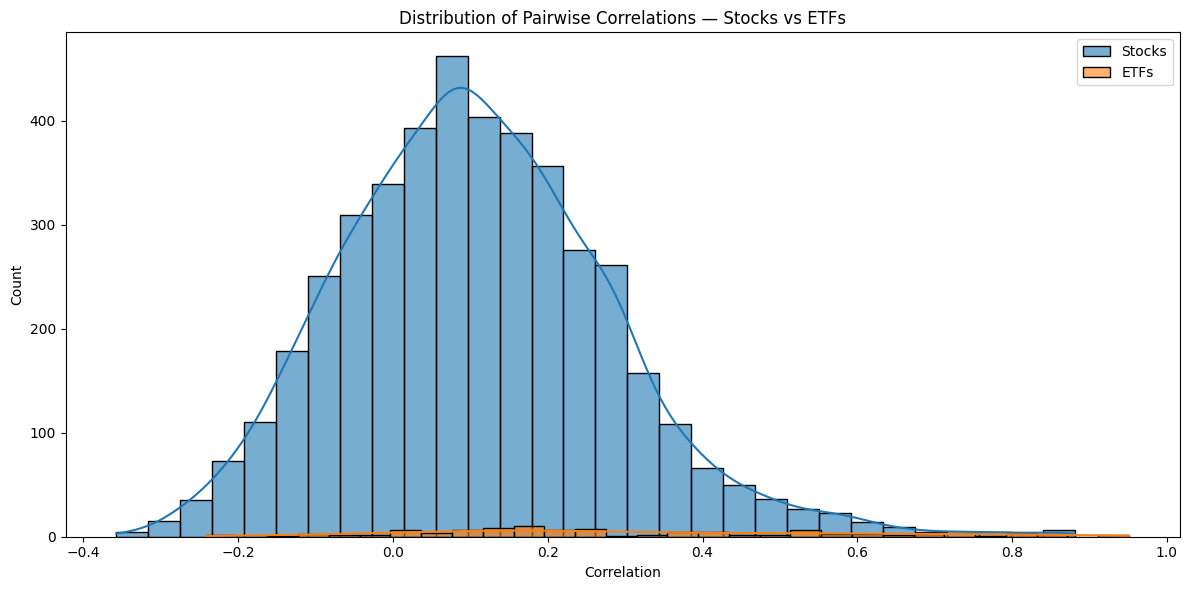

In [35]:
plt.figure(figsize=(12,6))

sns.histplot(
    stock_corr_values,
    bins=30,
    kde=True,
    label="Stocks",
    alpha=0.6
)

sns.histplot(
    etf_corr_values,
    bins=30,
    kde=True,
    label="ETFs",
    alpha=0.6
)

plt.legend()

plt.title(
    "Distribution of Pairwise Correlations — Stocks vs ETFs"
)

plt.xlabel("Correlation")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### 19.2 Volatility Comparison

In [36]:
stock_volatility = (recent_stock_returns.std()* np.sqrt(252))

etf_volatility = (recent_etf_returns.std()* np.sqrt(252))

comparison = pd.DataFrame({
    "Stocks": [stock_volatility.mean()],
    "ETFs": [etf_volatility.mean()]
})

comparison

,Stocks,ETFs
0,0.319126,0.162415


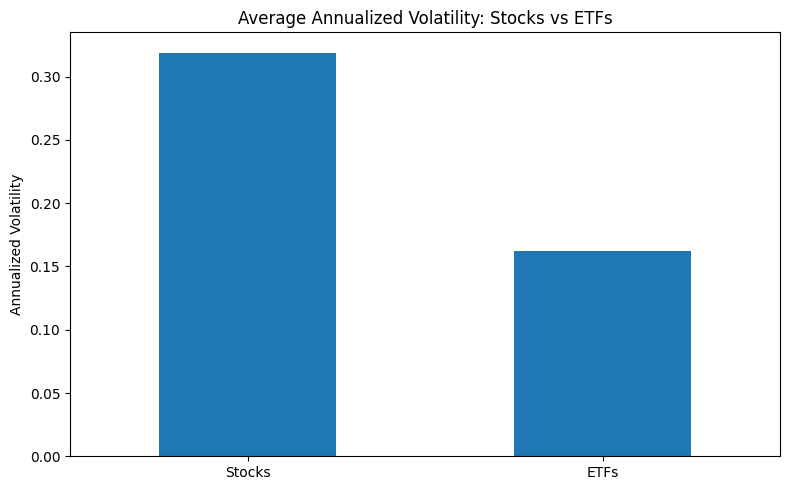

In [37]:
comparison.T.plot(
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.ylabel(
    "Annualized Volatility"
)

plt.title(
    "Average Annualized Volatility: Stocks vs ETFs"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

**Key Finding:**

- ETFs exhibit higher average pairwise correlations than individual stocks, which is expected given that ETFs track diversified baskets of securities.
- The standard deviation of ETF pairwise correlations is lower than for stocks, indicating more consistent relationships across ETF pairs.
- Stocks exhibit higher average annualized volatility than ETFs, reflecting the diversification benefit of ETFs — firm-specific risk is largely diversified away within an ETF basket.
- Because ETF relationships are driven primarily by broad market and sector factors rather than idiosyncratic events, they may be more persistent over time — a useful property when identifying pairs for further analysis.

## 20. Year-wise Correlation Analysis

Long-term average correlations may obscure important changes in relationships that occur across different market regimes. Analysing correlations year by year reveals how relationships evolve over time.

A static correlation estimated over the full sample is an average across all regimes — periods of risk-on, risk-off, sector rotations, and macro shocks. Year-wise analysis makes these structural changes visible.

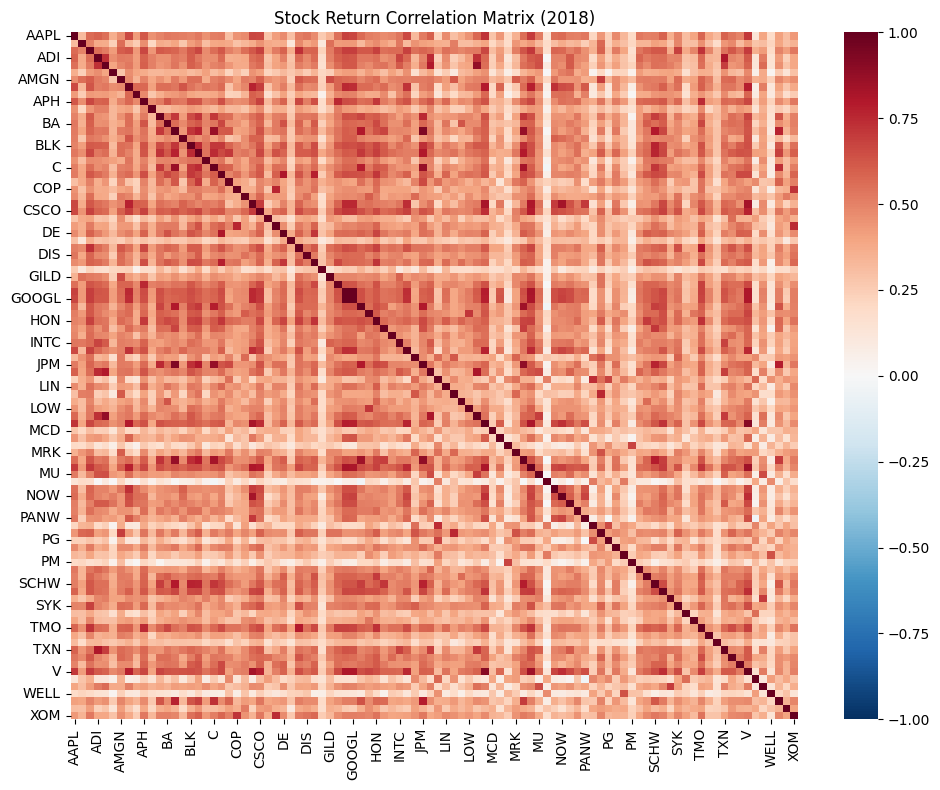



Top 5 Correlated Pairs — 2018
     Stock_1 Stock_2  Correlation                    Company_1  \
1267     BAC     JPM     0.932454  Bank of America Corporation   
5069      MA       V     0.914003      Mastercard Incorporated   
4288     JPM      MS     0.883711         JPMorgan Chase & Co.   
428     AMAT    LRCX     0.881776      Applied Materials, Inc.   
1280     BAC      MS     0.873104  Bank of America Corporation   

                     Company_2  
1267      JPMorgan Chase & Co.  
5069                 Visa Inc.  
4288            Morgan Stanley  
428   Lam Research Corporation  
1280            Morgan Stanley  


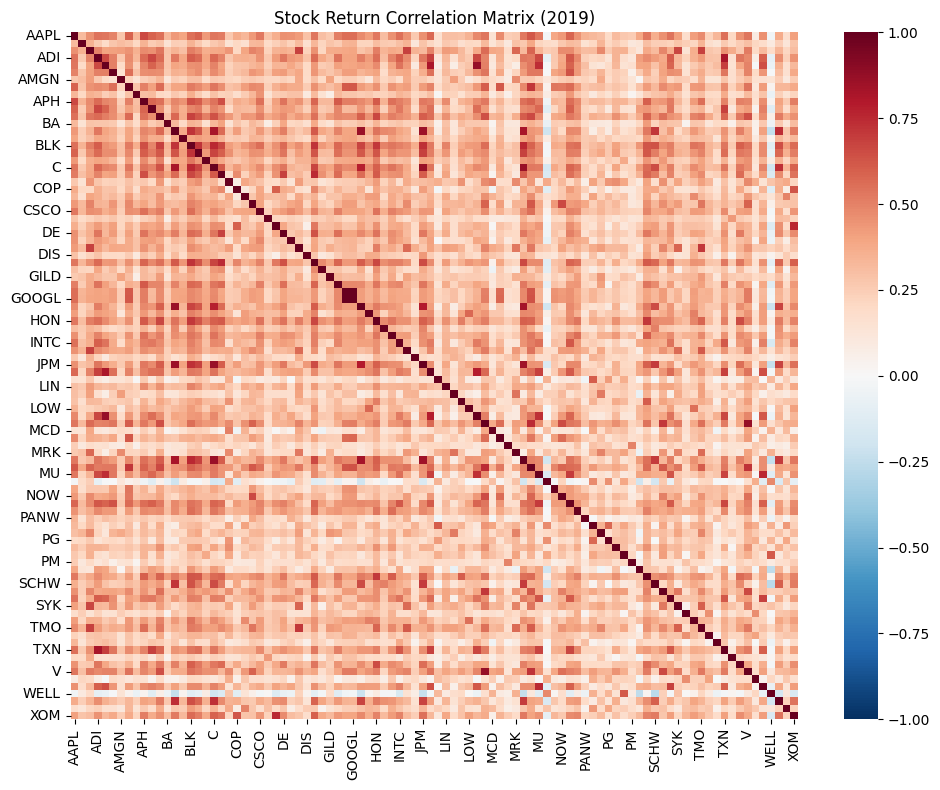



Top 5 Correlated Pairs — 2019
     Stock_1 Stock_2  Correlation                    Company_1  \
428     AMAT    LRCX     0.874613      Applied Materials, Inc.   
5069      MA       V     0.867474      Mastercard Incorporated   
1737       C     JPM     0.866012               Citigroup Inc.   
1259     BAC      GS     0.860421  Bank of America Corporation   
1750       C      MS     0.859550               Citigroup Inc.   

                          Company_2  
428        Lam Research Corporation  
5069                      Visa Inc.  
1737           JPMorgan Chase & Co.  
1259  The Goldman Sachs Group, Inc.  
1750                 Morgan Stanley  


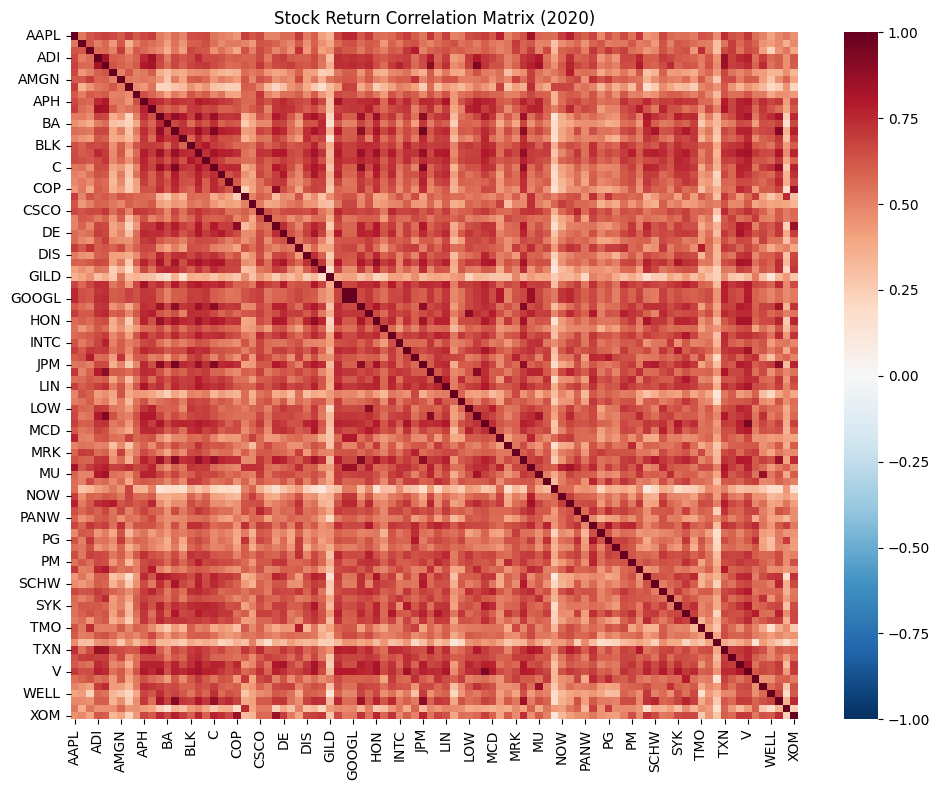



Top 5 Correlated Pairs — 2020
     Stock_1 Stock_2  Correlation                      Company_1  \
1267     BAC     JPM     0.953740    Bank of America Corporation   
5069      MA       V     0.942210        Mastercard Incorporated   
428     AMAT    LRCX     0.927715        Applied Materials, Inc.   
1240     BAC       C     0.926720    Bank of America Corporation   
3536      GS      MS     0.917180  The Goldman Sachs Group, Inc.   

                     Company_2  
1267      JPMorgan Chase & Co.  
5069                 Visa Inc.  
428   Lam Research Corporation  
1240            Citigroup Inc.  
3536            Morgan Stanley  


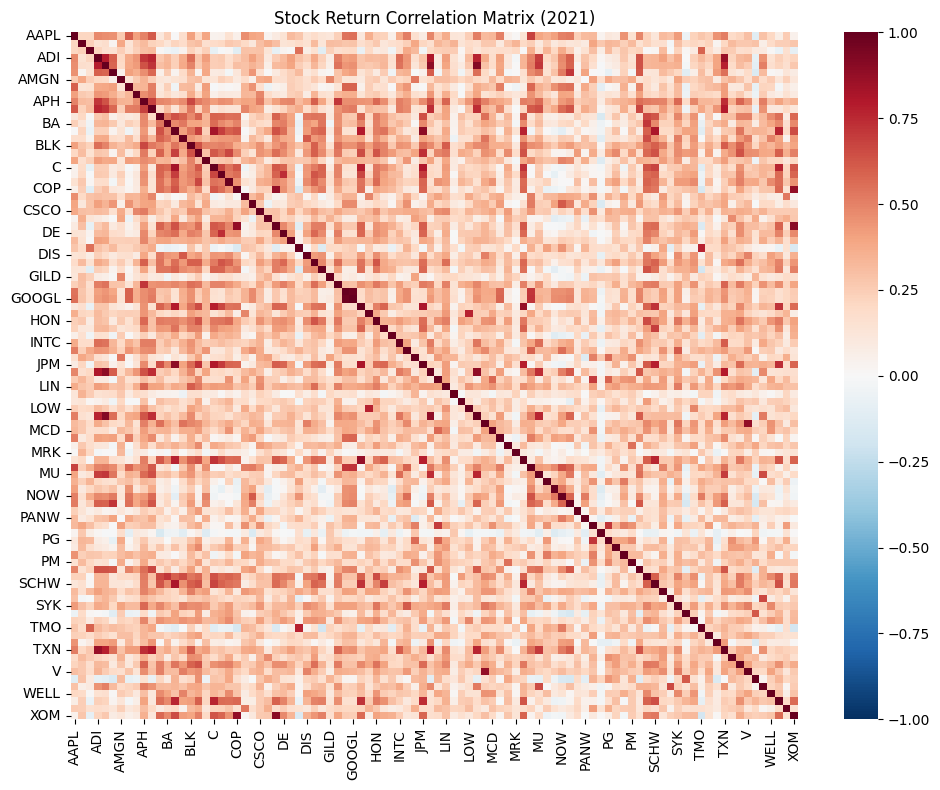



Top 5 Correlated Pairs — 2021
     Stock_1 Stock_2  Correlation                    Company_1  \
428     AMAT    LRCX     0.918455      Applied Materials, Inc.   
2537     CVX     XOM     0.904809          Chevron Corporation   
1267     BAC     JPM     0.895760  Bank of America Corporation   
422     AMAT    KLAC     0.894590      Applied Materials, Inc.   
4376    KLAC    LRCX     0.886740              KLA Corporation   

                     Company_2  
428   Lam Research Corporation  
2537   Exxon Mobil Corporation  
1267      JPMorgan Chase & Co.  
422            KLA Corporation  
4376  Lam Research Corporation  


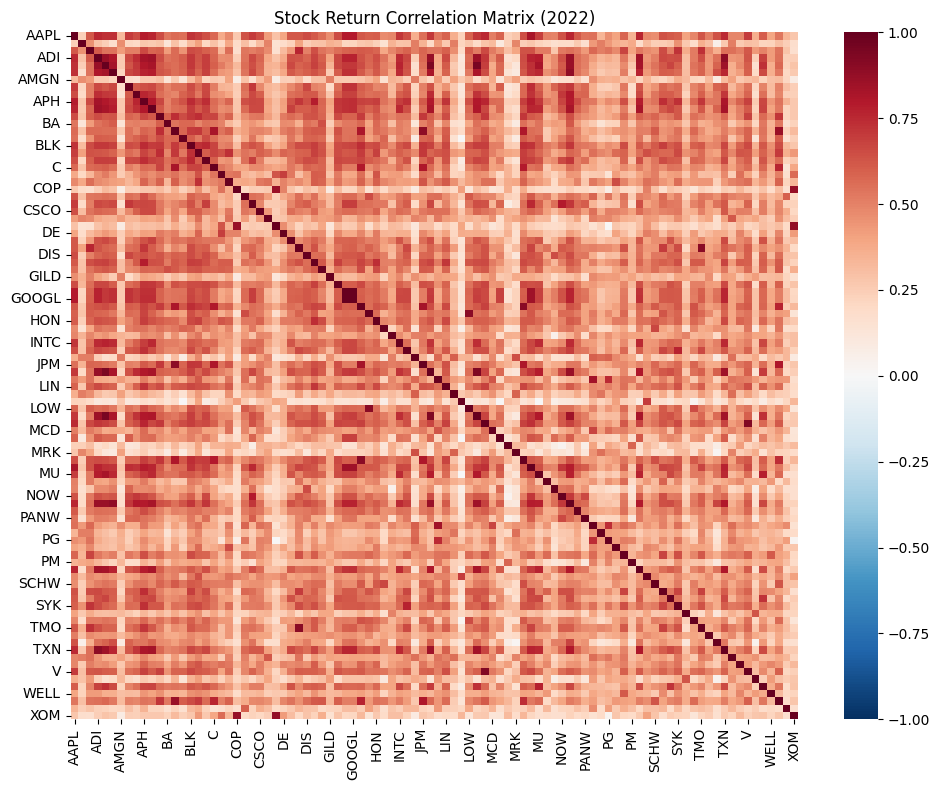



Top 5 Correlated Pairs — 2022
     Stock_1 Stock_2  Correlation                      Company_1  \
428     AMAT    LRCX     0.945555        Applied Materials, Inc.   
422     AMAT    KLAC     0.937541        Applied Materials, Inc.   
4376    KLAC    LRCX     0.934810                KLA Corporation   
5069      MA       V     0.925411        Mastercard Incorporated   
3536      GS      MS     0.900271  The Goldman Sachs Group, Inc.   

                     Company_2  
428   Lam Research Corporation  
422            KLA Corporation  
4376  Lam Research Corporation  
5069                 Visa Inc.  
3536            Morgan Stanley  


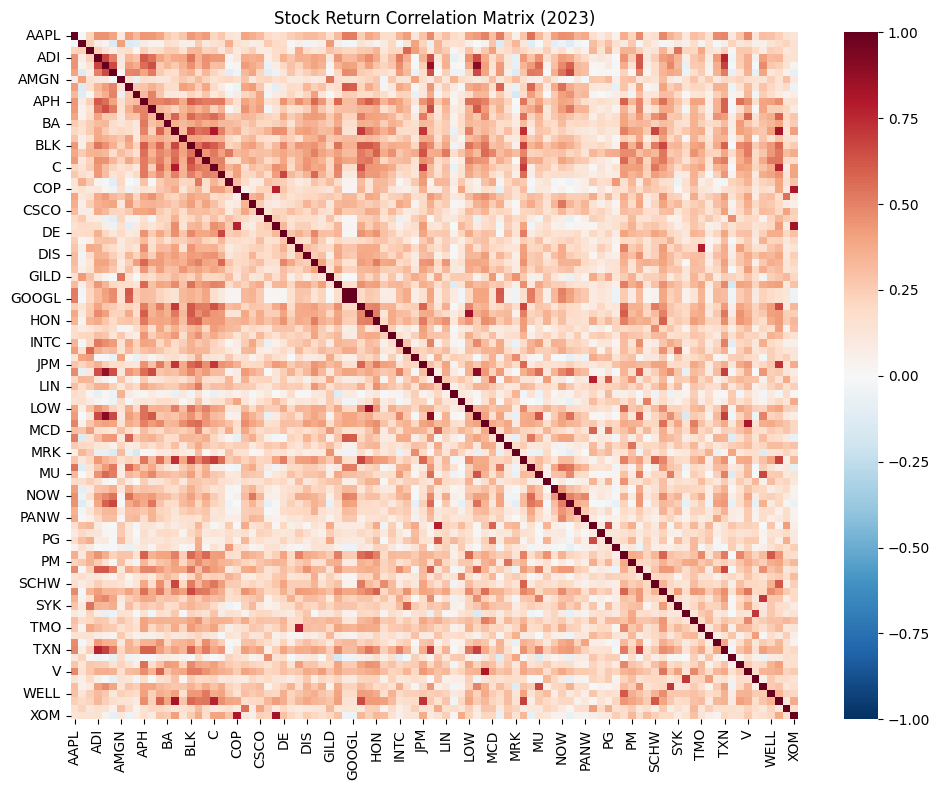



Top 5 Correlated Pairs — 2023
     Stock_1 Stock_2  Correlation                Company_1  \
428     AMAT    LRCX     0.904733  Applied Materials, Inc.   
4376    KLAC    LRCX     0.893602          KLA Corporation   
422     AMAT    KLAC     0.874433  Applied Materials, Inc.   
3623      HD     LOW     0.850853     The Home Depot, Inc.   
2537     CVX     XOM     0.840412      Chevron Corporation   

                     Company_2  
428   Lam Research Corporation  
4376  Lam Research Corporation  
422            KLA Corporation  
3623    Lowe's Companies, Inc.  
2537   Exxon Mobil Corporation  


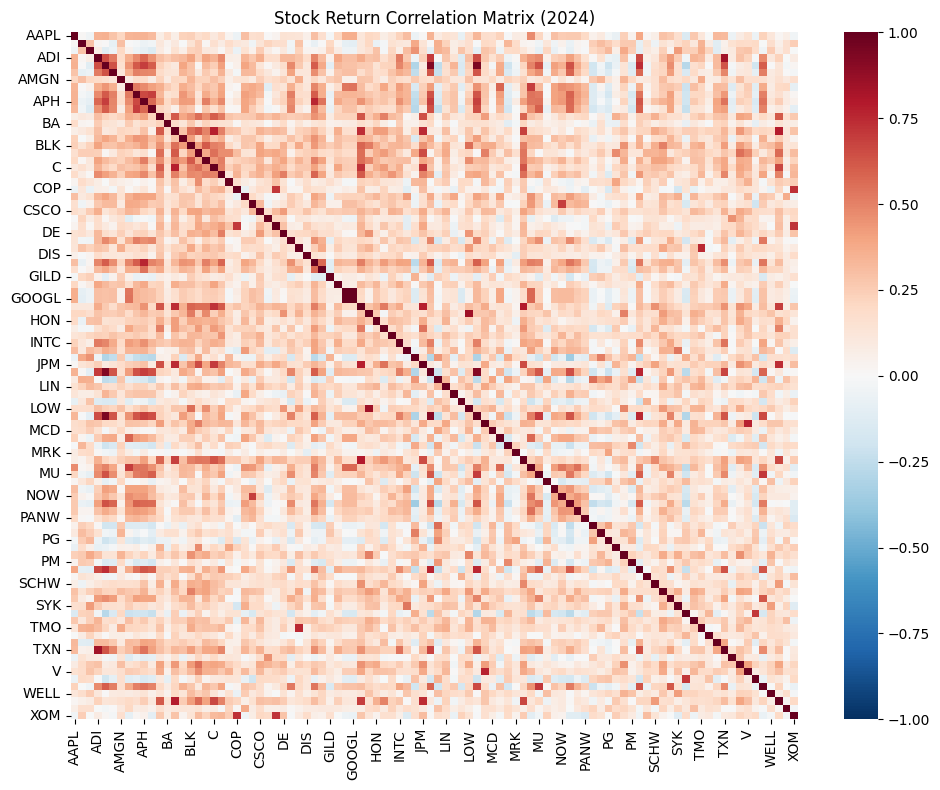



Top 5 Correlated Pairs — 2024
     Stock_1 Stock_2  Correlation                Company_1  \
428     AMAT    LRCX     0.937843  Applied Materials, Inc.   
422     AMAT    KLAC     0.926917  Applied Materials, Inc.   
4376    KLAC    LRCX     0.917106          KLA Corporation   
3623      HD     LOW     0.848491     The Home Depot, Inc.   
366      ADI     TXN     0.840643     Analog Devices, Inc.   

                           Company_2  
428         Lam Research Corporation  
422                  KLA Corporation  
4376        Lam Research Corporation  
3623          Lowe's Companies, Inc.  
366   Texas Instruments Incorporated  


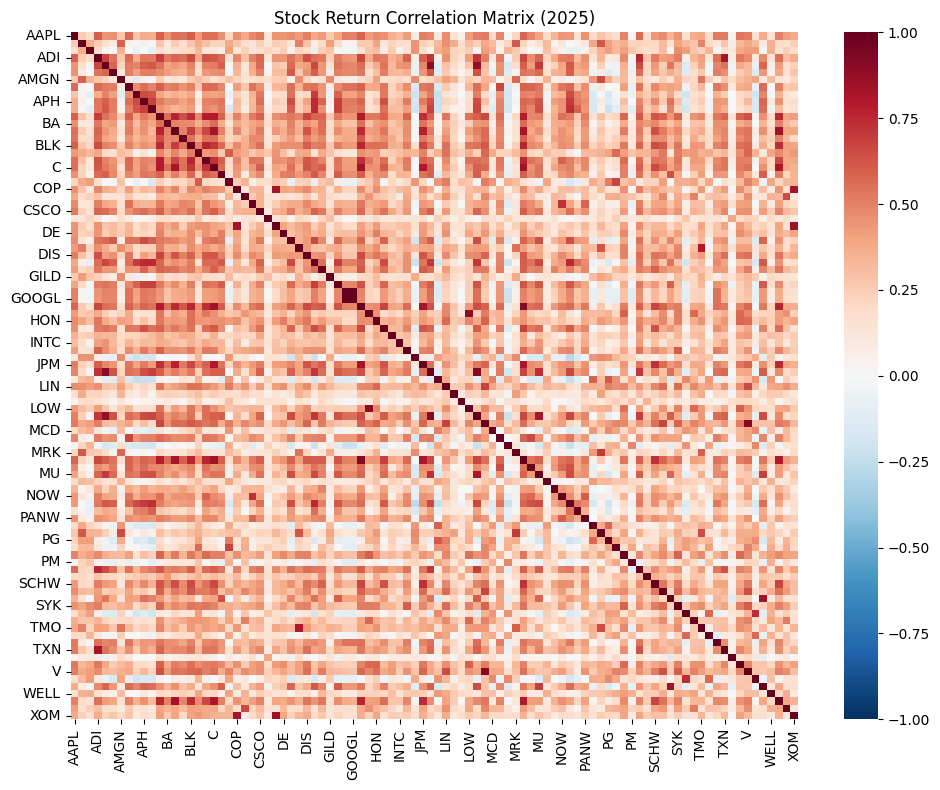



Top 5 Correlated Pairs — 2025
     Stock_1 Stock_2  Correlation                      Company_1  \
3536      GS      MS     0.913762  The Goldman Sachs Group, Inc.   
4376    KLAC    LRCX     0.912693                KLA Corporation   
5069      MA       V     0.912208        Mastercard Incorporated   
422     AMAT    KLAC     0.893117        Applied Materials, Inc.   
3623      HD     LOW     0.886905           The Home Depot, Inc.   

                     Company_2  
3536            Morgan Stanley  
4376  Lam Research Corporation  
5069                 Visa Inc.  
422            KLA Corporation  
3623    Lowe's Companies, Inc.  


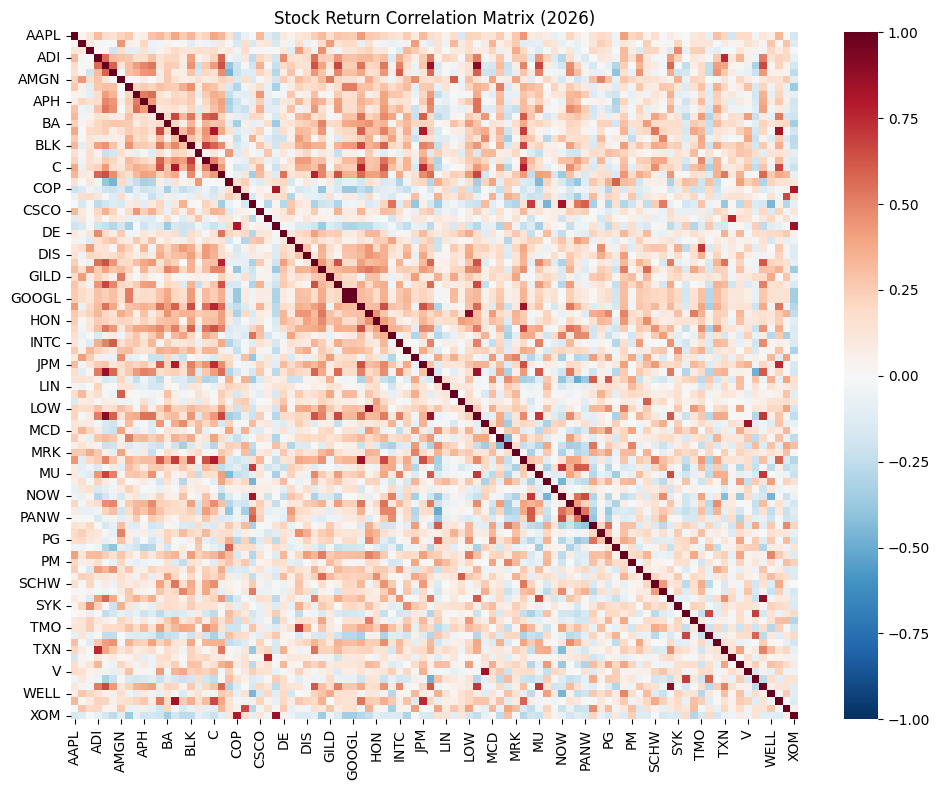



Top 5 Correlated Pairs — 2026
     Stock_1 Stock_2  Correlation                        Company_1  \
3623      HD     LOW     0.902136             The Home Depot, Inc.   
428     AMAT    LRCX     0.899468          Applied Materials, Inc.   
7327     STX     WDC     0.889842  Seagate Technology Holdings plc   
422     AMAT    KLAC     0.856420          Applied Materials, Inc.   
2537     CVX     XOM     0.853158              Chevron Corporation   

                        Company_2  
3623       Lowe's Companies, Inc.  
428      Lam Research Corporation  
7327  Western Digital Corporation  
422               KLA Corporation  
2537      Exxon Mobil Corporation  


In [38]:
years = sorted(returns.index.year.unique())

yearly_top_pairs = {}

for year in years:

    yearly_data = stock_returns[
        stock_returns.index.year == year
    ]

    if len(yearly_data) < 60:
        print(f"Skipping {year}")
        continue

    yearly_corr = yearly_data.corr()

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        yearly_corr,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1
    )

    plt.title(
        f"Stock Return Correlation Matrix ({year})"
    )

    plt.tight_layout()
    plt.show()

    upper_yr = yearly_corr.where(
        np.triu(np.ones(yearly_corr.shape),k=1).astype(bool)
    )

    pairs = upper_yr.stack().reset_index()

    pairs.columns = [
        "Stock_1",
        "Stock_2",
        "Correlation"
    ]

    pairs = remove_same_company_pairs(
        pairs,
        "Stock_1",
        "Stock_2"
    )

    pairs = ( pairs.sort_values("Correlation",ascending=False).head(5))

    yearly_top_pairs[year] = pairs

    print("\n")
    print("=" * 50)
    print(f"Top 5 Correlated Pairs — {year}")
    print("=" * 50)
    print(pairs)

- Same-company pairs (e.g. GOOG–GOOGL) are excluded from year-wise results 
  by the same-company filter applied in each loop iteration.
- Year-wise analysis covers stock pairs only; ETF relationships are 
  examined separately in Section 21.2.
- Semiconductor pairs (AMAT–LRCX, AMAT–KLAC) and financial pairs 
  (BAC–JPM, MA–V) are among the most consistently recurring relationships.

In [39]:
from collections import Counter

pair_counter = Counter()

for year, pairs in yearly_top_pairs.items():

    for _, row in pairs.iterrows():

        pair_name = (
            row["Stock_1"]
            + " - "
            + row["Stock_2"]
        )

        pair_counter[pair_name] += 1

pair_frequency = (
    pd.DataFrame(
        pair_counter.items(),
        columns=[
            "Pair",
            "Years Appeared in Top 5"
        ]
    )
    .sort_values(
        "Years Appeared in Top 5",
        ascending=False
    )
)

print(
    "Pairs appearing most frequently in the yearly top-5:"
)

pair_frequency

Pairs appearing most frequently in the yearly top-5:


,Pair,Years Appeared in Top 5
3,AMAT - LRCX,8
11,AMAT - KLAC,6
1,MA - V,5
12,KLAC - LRCX,5
13,HD - LOW,4
0,BAC - JPM,3
9,GS - MS,3
10,CVX - XOM,3
2,JPM - MS,1
4,BAC - MS,1


### Sector Relationship Analysis

Most highly correlated stock pairs belong to the same industry or sector.

This suggests that common business drivers and industry-specific factors play a major role in determining return correlations.

## 21. Rolling Correlation Analysis

Static correlation provides a single relationship estimate over the entire sample period. However, relationships between assets can change through time.

To evaluate relationship stability, a 252-day rolling correlation window is used.

Why 252?

- Approximately 252 trading days occur in one year.
- The window captures long-term relationship dynamics.
- Rolling correlation helps identify periods where relationships strengthen or weaken.

In [40]:
# Helper function to compute rolling correlation
def compute_rolling_corr(data, asset1, asset2, window=252):
    return data[asset1].rolling(window).corr(data[asset2])

In [41]:
full_stock_corr = stock_returns.corr()

full_etf_corr = etf_returns.corr()

In [42]:
# Top 5 stock pairs for rolling correlation

top_stock_pairs_5 = top_stock_pairs.head(5)

stock_pairs_to_plot = list(
    zip(
        top_stock_pairs_5["Stock_1"],
        top_stock_pairs_5["Stock_2"]
    )
)

# Top 5 ETF pairs for rolling correlation

top_etf_pairs_5 = top_etf_pairs.head(5)

etf_pairs_to_plot = list(
    zip(
        top_etf_pairs_5["ETF_1"],
        top_etf_pairs_5["ETF_2"]
    )
)

print("Stock Pairs:")
print(stock_pairs_to_plot)

print()

print("ETF Pairs:")
print(etf_pairs_to_plot)

Stock Pairs:
[('HD', 'LOW'), ('AMAT', 'LRCX'), ('STX', 'WDC'), ('MA', 'V'), ('KLAC', 'LRCX')]

ETF Pairs:
[('QQQ', 'XLK'), ('SPY', 'QQQ'), ('SPY', 'XLK'), ('SPY', 'DIA'), ('SPY', 'IWM')]


## 21.1 Rolling Correlation — Stocks

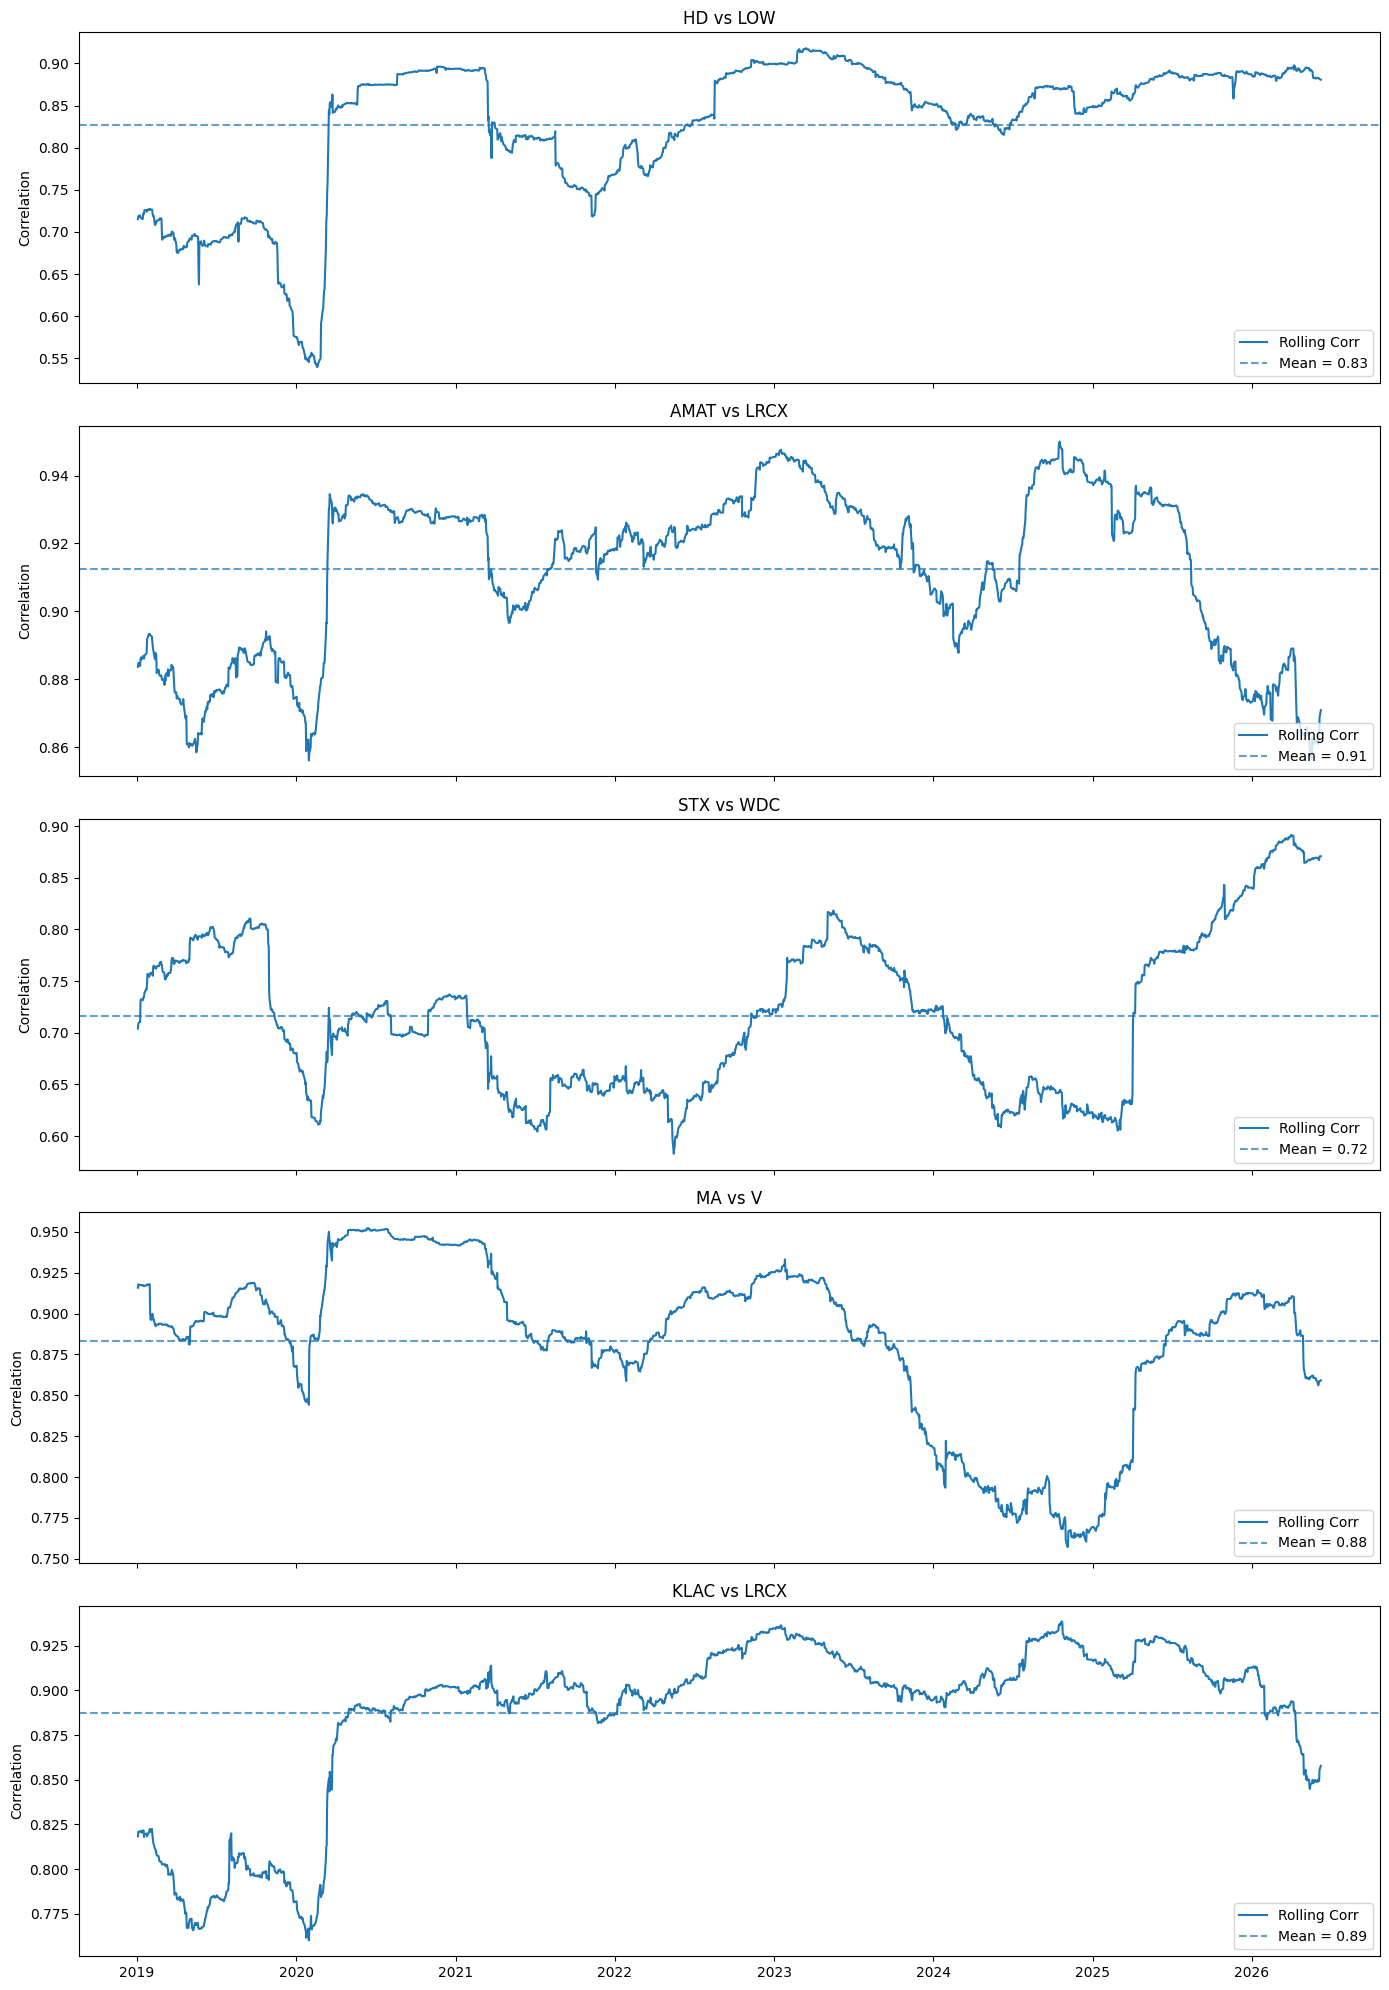

In [43]:
fig, axes = plt.subplots(
    len(stock_pairs_to_plot),
    1,
    figsize=(14, 4 * len(stock_pairs_to_plot)),
    sharex=True
)

if len(stock_pairs_to_plot) == 1:
    axes = [axes]

for ax, (s1, s2) in zip(axes, stock_pairs_to_plot):

    rcorr = compute_rolling_corr(stock_returns, s1, s2, 252).dropna()

    ax.plot(rcorr.index, rcorr, label="Rolling Corr")

    ax.axhline(        
    rcorr.mean(),        
    linestyle="--",
    alpha=0.7,
    label=f"Mean = {rcorr.mean():.2f}"
)                       
    ax.legend(loc="lower right")
    ax.set_title(f"{s1} vs {s2}")
    ax.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

In [44]:
rolling_summary = []
# Summary cell
for s1, s2 in stock_pairs_to_plot:
    rcorr = compute_rolling_corr(stock_returns, s1, s2).dropna()
    rolling_summary.append({
        "Pair":              f"{s1}-{s2}",
        "Static Corr":       round(full_stock_corr.loc[s1, s2], 3),
        "Mean Rolling Corr": round(rcorr.mean(), 3),
        "Min Rolling Corr":  round(rcorr.min(), 3),
        "Max Rolling Corr":  round(rcorr.max(), 3),
        "Std Rolling Corr":  round(rcorr.std(), 3),
    })


rolling_summary = pd.DataFrame(
    rolling_summary
)

rolling_summary

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr,Std Rolling Corr
0,HD-LOW,0.837,0.827,0.540,0.918,0.081
1,AMAT-LRCX,0.911,0.913,0.856,0.950,0.023
2,STX-WDC,0.740,0.716,0.583,0.891,0.074
3,MA-V,0.903,0.883,0.757,0.952,0.050
4,KLAC-LRCX,0.887,0.887,0.760,0.939,0.045


**Observations (Stocks):** Several stock pairs maintained consistently high rolling correlations across the sample period. Some relationships weakened during periods of market stress, while semiconductor and financial-sector pairs displayed particularly stable relationships.



## 21.2 Rolling Correlation — ETF

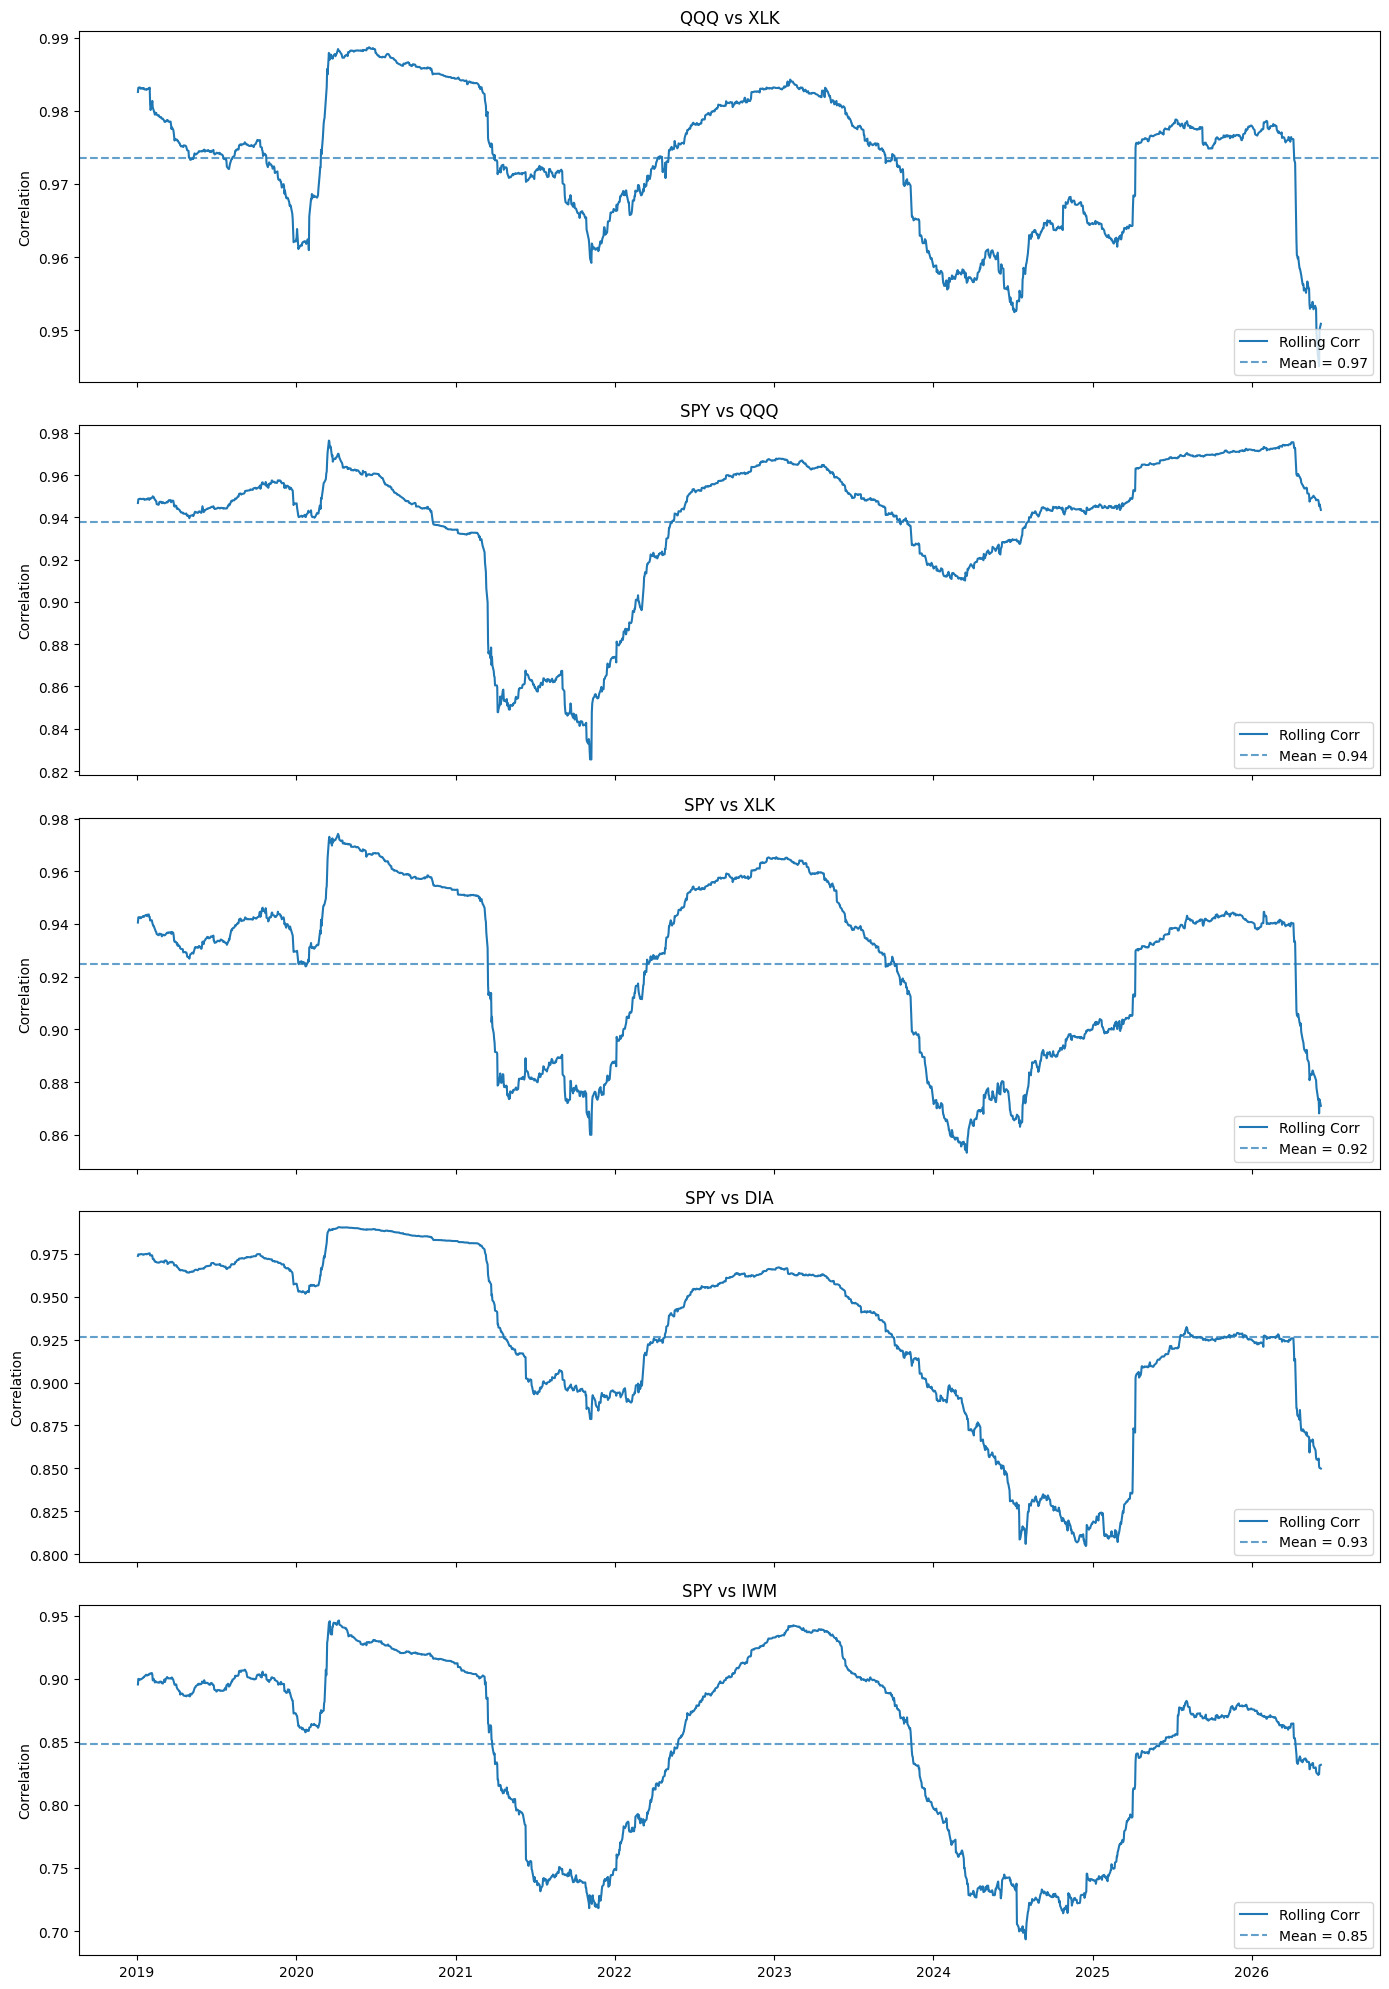

In [45]:
fig, axes = plt.subplots(
    len(etf_pairs_to_plot),
    1,
    figsize=(14, 4 * len(etf_pairs_to_plot)),
    sharex=True
)
if len(etf_pairs_to_plot) == 1:
    axes = [axes]

for ax, (e1, e2) in zip(axes, etf_pairs_to_plot):

    rcorr = compute_rolling_corr(etf_returns, e1, e2, 252).dropna()
    ax.plot(rcorr.index, rcorr, label="Rolling Corr")
    ax.axhline( rcorr.mean(), linestyle="--", alpha=0.7, label=f"Mean = {rcorr.mean():.2f}")
    ax.set_title(f"{e1} vs {e2}")
    ax.set_ylabel("Correlation")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [46]:
# Rolling correlation summary table for ETF pairs
etf_summary = []
for e1, e2 in etf_pairs_to_plot:
    rcorr = compute_rolling_corr(etf_returns, e1, e2).dropna()
    etf_summary.append({
        "Pair": f"{e1} – {e2}",
        "Static Corr":       round(full_etf_corr.loc[e1, e2], 3),
        "Mean Rolling Corr": round(rcorr.mean(), 3),
        "Min Rolling Corr":  round(rcorr.min(), 3),
        "Max Rolling Corr":  round(rcorr.max(), 3),
        "Std Rolling Corr":  round(rcorr.std(), 3)
    })

etf_rolling_summary = pd.DataFrame(etf_summary)
etf_rolling_summary

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr,Std Rolling Corr
0,QQQ – XLK,0.974,0.974,0.945,0.989,0.009
1,SPY – QQQ,0.937,0.938,0.825,0.976,0.033
2,SPY – XLK,0.929,0.925,0.853,0.974,0.032
3,SPY – DIA,0.945,0.927,0.805,0.991,0.050
4,SPY – IWM,0.867,0.848,0.693,0.946,0.071


**Observations (ETFs):** ETF relationships were generally more stable than stock relationships. QQQ–XLK exhibited persistently strong correlation due to overlapping technology holdings. Broad-market ETFs maintained strong relationships throughout the full sample period. The lower standard deviation of rolling correlations for ETF pairs (compared to stock pairs) provides quantitative support for their greater relationship stability.

## 22. Final Summary

In [47]:
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\nDataset Overview")
print("-" * 30)
print(f"Total Assets: {returns.shape[1]}")
print(f"Observation Period: {returns.index.min().date()} to {returns.index.max().date()}")

print("\nPerformance Analysis")
print("-" * 30)
print("Top Performing Assets:")
print(performance.head(5))

print("\nVolatility Analysis")
print("-" * 30)
print("Most Volatile Assets:")
print(top_volatility.head(5))

print("\nLeast Volatile Assets:")
print(low_volatility.head(5))

print("\nCorrelation Analysis (Recent 1-Year Period)")
print("-" * 30)
print("Top Stock Pairs:")
print(top_stock_pairs[["Stock_1", "Stock_2", "Correlation"]].head(5))

print("\nTop ETF Pairs:")
print(top_etf_pairs[["ETF_1", "ETF_2", "Correlation"]].head(5))

print("\nStocks vs ETFs")
print("-" * 30)
print(f"Average Stock Correlation: {stock_corr_values.mean():.3f}")

print(f"Average ETF Correlation: {etf_corr_values.mean():.3f}")

print(f"Average Stock Volatility: {stock_volatility.mean():.3f}")

print(f"Average ETF Volatility: {etf_volatility.mean():.3f}")

print("\nYearly Correlation Stability")
print("-" * 30)

print( pair_frequency.head(10))

print("\nRolling Correlation Summary")
print("-" * 30)

print(
    rolling_summary[
        [
            "Pair",
            "Mean Rolling Corr",
            "Min Rolling Corr",
            "Max Rolling Corr"
        ]
    ]
)
print("\nETF Rolling Correlation Summary")
print("-" * 30)

print(
    etf_rolling_summary[
        [
            "Pair",
            "Mean Rolling Corr",
            "Min Rolling Corr",
            "Max Rolling Corr"
        ]
    ]
)
print("\nKey Findings")
print("-" * 30)

print("• Correlations vary across time and are not constant.")

print("• ETFs generally exhibit stronger and more stable correlations than individual stocks.")

print("• Highly correlated pairs are often concentrated within similar sectors.")

print("• Rolling correlations reveal periods of strengthening and weakening relationships.")

print("• Several stock pairs consistently appear among the most correlated across multiple years.")

print("• Recent one-year analysis provides a more current view of market relationships.")

print("\nEDA Completed Successfully.")

FINAL EDA SUMMARY

Dataset Overview
------------------------------
Total Assets: 109
Observation Period: 2018-01-03 to 2026-06-08

Performance Analysis
------------------------------
Top Performing Assets:
AMD     44.656649
NVDA    42.384707
STX     28.106125
KLAC    22.524279
MU      22.288392
Name: 2026-06-08 00:00:00, dtype: float64

Volatility Analysis
------------------------------
Most Volatile Assets:
TSLA    0.626878
AMD     0.562325
MU      0.517021
NVDA    0.507083
WDC     0.505205
dtype: float64

Least Volatile Assets:
TLT    0.154920
XLP    0.155683
GLD    0.166553
XLV    0.174385
DIA    0.187861
dtype: float64

Correlation Analysis (Recent 1-Year Period)
------------------------------
Top Stock Pairs:
     Stock_1 Stock_2  Correlation
3623      HD     LOW     0.880636
428     AMAT    LRCX     0.870888
7327     STX     WDC     0.870794
5069      MA       V     0.859181
4376    KLAC    LRCX     0.857795

Top ETF Pairs:
   ETF_1 ETF_2  Correlation
19   QQQ   XLK     0.950908
